# **메인 퀘스트: 고객 행동 예측 및 고객 데이터 분석**

Orange Telecom 고객 이탈 데이터셋은 깔끔하게 정리된 고객 활동 데이터(특성들)와 고객이 구독을 취소했는지 여부를 보여주는 이탈 라벨로 구성되어 있고, 이걸 가지고 예측 모델을 만듭니다. 두 개의 데이터셋이 있는데, churn-80이랑 churn-20을 다운받을 수 있습니다.

두 데이터셋은 같은 데이터에서 나온 건데 80/20 비율로 나눠져있습니다. 머신러닝 모델을 만들 때는 데이터가 많을수록 좋으니까, 큰 데이터셋(churn-80)은 모델 학습이랑 교차 검증할 때 쓰고, 작은 데이터셋(churn-20)은 마지막에 최종 테스트하고 모델 성능 평가할 때 쓸 수 있습니다. 즉 churn-80은 학습용, churn-20은 모델 성능 평가용 데이터셋입니다.

다음의 가이드라인을 참고하여 각 팀별로 인사이트를 도출해주세요.

(다음의 가이드라인은 예시일뿐 정확하게 가이드라인을 따르거나 할 필요는 없습니다.)

## **1. 문제 정의 및 데이터 이해**

**목표 설정**

- 비즈니스 문제: 통신사 고객 이탈을 예측하여 선제적 유지 전략 수립
- 분석 목표: 이탈에 영향을 미치는 주요 요인 파악 및 이탈 예측 모델 구축
- 성공 지표: 모델 정확도, Precision/Recall, F1-score, 비즈니스 액션 가능성 등

**데이터셋 구조 파악**

- churn-80.csv (훈련/검증용), churn-20.csv (최종 테스트용) 파일 로드
- 데이터 크기, 변수 개수, 데이터 타입 확인
- 각 변수의 의미와 비즈니스 맥락 이해

In [1]:
# 00.라이브러리 불러오기

# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


plt.rcParams.update({
    "figure.figsize": (10, 6),   # ⭐ grid용 한 장
    "figure.dpi": 90,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

sns.set_style("whitegrid")



# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:

# =========================
# 01. 데이터 불러오기
# =========================
print("\n" + "="*60)
print("01. 데이터 불러오기")
print("="*60)

train_df = pd.read_csv("churn-bigml-80.csv")
test_df  = pd.read_csv("churn-bigml-20.csv")

print("✅ 데이터 로드 완료")


# =========================
# 02. 데이터 크기 확인 (전체데이터수, 컬럼수)
# =========================
print("\n" + "="*60)
print("02. 데이터 크기 확인 (행 수, 컬럼 수)")
print("="*60)

print("train_df shape:", train_df.shape)
print("test_df shape :", test_df.shape)


# =========================
# 03. 컬럼 이름 보기
# =========================
print("\n" + "="*60)
print("03. 컬럼 이름 확인")
print("="*60)

print(train_df.columns)


# =========================
# 04. 타겟 변수 확인
# True → 이탈
# False → 유지
# =========================
print("\n" + "="*60)
print("04. 타겟 변수(Churn) 분포 확인")
print("="*60)

print(train_df["Churn"].value_counts())


# =========================
# 05. 이탈률 계산
# “전체 고객 중 약 14~15%가 이탈 고객으로 나타났다.”
# =========================
print("\n" + "="*60)
print("05. 이탈률 계산 (Churn=True 비율)")
print("="*60)

print(train_df["Churn"].value_counts(normalize=True))


# =========================
# 06. 데이터 타입 확인
# (문자형 변수와 수치형 변수가 혼재되어 있다.)
# =========================
print("\n" + "="*60)
print("06. 데이터 타입 확인")
print("="*60)

print(train_df.dtypes)


# =========================
# 07. 결측치 확인
# (거의 없음)
# (“본 데이터셋에는 결측치가 존재하지 않는다.”)
# =========================
print("\n" + "="*60)
print("07. 결측치 확인")
print("="*60)

print(train_df.isnull().sum())


# =========================
# 08. 범주형 vs 수치형 나누기 (자동)
# (“범주형 변수는 인코딩이 필요하다.”)
# =========================
print("\n" + "="*60)
print("08. 변수 타입 구분 (범주형 / 수치형)")
print("="*60)

categorical_cols = train_df.select_dtypes(include="object").columns
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

print("범주형 변수:")
print(categorical_cols)

print("\n수치형 변수:")
print(numeric_cols)



01. 데이터 불러오기
✅ 데이터 로드 완료

02. 데이터 크기 확인 (행 수, 컬럼 수)
train_df shape: (2666, 20)
test_df shape : (667, 20)

03. 컬럼 이름 확인
Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

04. 타겟 변수(Churn) 분포 확인
Churn
False    2278
True      388
Name: count, dtype: int64

05. 이탈률 계산 (Churn=True 비율)
Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64

06. 데이터 타입 확인
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day mi

## **2. 데이터 전처리**

**결측치 처리**

- 결측치 존재 여부 확인
- 결측치 처리 전략 수립: 삭제, 평균/중앙값 대체, 또는 별도 카테고리 생성
- 처리 방법에 대한 근거 수립

**이상치 탐지 및 처리**

- 이상치가 실제 오류인지 극단값인지 판단
- 비즈니스 맥락을 고려한 처리 방법 결정 (유지/제거/변환 등)

**데이터 타입 변환**

- 범주형 변수(State, International plan, Voice mail plan) 식별
- 수치형 변수 스케일 확인 (통화 시간, 요금, 횟수 등)
- 필요시 변수 타입 변환 및 인코딩
    - ex) yes→1, no→0 / 라벨 인코딩 / 원핫 인코딩 등

In [3]:
# =========================
# 09. 데이터 전처리 시작
# =========================
print("\n" + "="*60)
print("09. 데이터 전처리 (Preprocessing)")
print("="*60)


# =========================
# 09-1. 결측치 존재 여부 재확인
# =========================
print("\n" + "-"*60)
print("09-1. 결측치 확인")
print("-"*60)

train_missing = train_df.isnull().sum().sum()
test_missing  = test_df.isnull().sum().sum()

print(f"train 결측치 총합: {train_missing}")
print(f"test  결측치 총합: {test_missing}")

if train_missing == 0 and test_missing == 0:
    print("✅ 결측치가 없어 별도 결측치 처리를 수행하지 않습니다.")
else:
    print("⚠️ 결측치가 존재합니다. (과제 기준: 중앙값/최빈값 대체 등을 고려)")


# =========================
# 09-2. (선택) 중복 행 확인
# =========================
print("\n" + "-"*60)
print("09-2. 중복 행 확인")
print("-"*60)

train_dup = train_df.duplicated().sum()
test_dup  = test_df.duplicated().sum()

print(f"train 중복 행 수: {train_dup}")
print(f"test  중복 행 수: {test_dup}")

if train_dup == 0 and test_dup == 0:
    print("✅ 중복 행이 없어 별도 제거를 수행하지 않습니다.")
else:
    print("⚠️ 중복 행이 존재합니다. 필요 시 제거(drop_duplicates) 고려.")


# =========================
# 09-3. 타겟(Churn) 분리
# =========================
print("\n" + "-"*60)
print("09-3. 타겟(Churn) 분리")
print("-"*60)

X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

print("✅ 분리 완료")
print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape,  "| y_test  shape:", y_test.shape)


# =========================
# 09-4. 범주형 변수 확인 (인코딩 대상)
#State, International plan, Voice mail plan은 범주형 변수로 식별되었다.
# =========================
print("\n" + "-"*60)
print("09-4. 범주형 변수 확인")
print("-"*60)

categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print("범주형 변수:", categorical_cols)

print("\n✅ 예상 인코딩 대상:")
print("- State (원핫 인코딩)")
print("- International plan / Voice mail plan (Yes/No → 1/0)")


# =========================
# 09-5. Yes/No → 1/0 변환 (이진 인코딩)
# =========================
print("\n" + "-"*60)
print("09-5. Yes/No 변수 이진 인코딩 (1/0)")
print("-"*60)

binary_cols = ["International plan", "Voice mail plan"]

print("변환 전 값 확인(훈련):")
for col in binary_cols:
    print(col, ":", X_train[col].unique())

for col in binary_cols:
    X_train[col] = X_train[col].map({"Yes": 1, "No": 0})
    X_test[col]  = X_test[col].map({"Yes": 1, "No": 0})

print("\n✅ 변환 완료 (Yes=1, No=0)")
print("변환 후 값 확인(훈련):")
for col in binary_cols:
    print(col, ":", X_train[col].unique())


# =========================
# 09-6. State 원핫 인코딩: 글자로 된 범주를, 모델이 이해할 수 있게 0과 1로 된 여러 개의 열”로 바꾸는 방법
# =========================
print("\n" + "-"*60)
print("09-6. State 원핫 인코딩 (One-Hot Encoding)")
print("-"*60)

print("인코딩 전 X_train 컬럼 수:", X_train.shape[1])

X_train = pd.get_dummies(X_train, columns=["State"], drop_first=True)
X_test  = pd.get_dummies(X_test, columns=["State"], drop_first=True)

print("✅ 원핫 인코딩 완료")
print("인코딩 후 X_train 컬럼 수:", X_train.shape[1])
print("인코딩 후 X_test  컬럼 수:", X_test.shape[1])


# =========================
# 09-7. train/test 컬럼 정렬 (중요!)
# =========================
print("\n" + "-"*60)
print("09-7. train/test 컬럼 맞추기 (align)")
print("-"*60)

before_train_cols = X_train.shape[1]
before_test_cols  = X_test.shape[1]

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

after_train_cols = X_train.shape[1]
after_test_cols  = X_test.shape[1]

print(f"정렬 전  train cols: {before_train_cols}, test cols: {before_test_cols}")
print(f"정렬 후  train cols: {after_train_cols}, test cols: {after_test_cols}")
print("✅ 학습/테스트 컬럼 구조를 동일하게 맞췄습니다.")


# =========================
# 09-8. (선택) 스케일링 준비 안내
# =========================
print("\n" + "-"*60)
print("09-8. (선택) 스케일링 안내")
print("-"*60)

print("✅ RandomForest는 스케일링 없이도 잘 동작합니다.")
print("✅ LogisticRegression / KNN은 스케일링(StandardScaler)을 권장합니다.")
print("👉 스케일링은 '모델 학습 단계'에서 적용해도 됩니다.")




09. 데이터 전처리 (Preprocessing)

------------------------------------------------------------
09-1. 결측치 확인
------------------------------------------------------------
train 결측치 총합: 0
test  결측치 총합: 0
✅ 결측치가 없어 별도 결측치 처리를 수행하지 않습니다.

------------------------------------------------------------
09-2. 중복 행 확인
------------------------------------------------------------
train 중복 행 수: 0
test  중복 행 수: 0
✅ 중복 행이 없어 별도 제거를 수행하지 않습니다.

------------------------------------------------------------
09-3. 타겟(Churn) 분리
------------------------------------------------------------
✅ 분리 완료
X_train shape: (2666, 19) | y_train shape: (2666,)
X_test  shape: (667, 19) | y_test  shape: (667,)

------------------------------------------------------------
09-4. 범주형 변수 확인
------------------------------------------------------------
범주형 변수: ['State', 'International plan', 'Voice mail plan']

✅ 예상 인코딩 대상:
- State (원핫 인코딩)
- International plan / Voice mail plan (Yes/No → 1/0)

---------------------------------------

## **3. EDA**

**단변량 분석 (Univariate Analysis)**

- 수치형 변수: 히스토그램, 박스플롯으로 분포 확인
- 기술통계량 산출 (평균, 중앙값, 표준편차, 사분위수)
- 범주형 변수: 빈도표, 막대그래프로 분포 확인
- 타겟 변수(Churn) 불균형 비율 계산

**이변량 분석 (Bivariate Analysis)**

- 수치형 변수 vs Churn: 박스플롯, 바이올린 플롯으로 그룹 간 차이 확인
- 범주형 변수 vs Churn: 교차표(Crosstab), 스택 바 차트로 이탈률 비교
- 통계적 검정: t-test (연속형), Chi-square test (범주형)로 유의성 확인
- 핵심 인사이트 도출: "고객 서비스 호출이 4회 이상인 고객의 이탈률이 50% 이상" 등

**다변량 분석 (Multivariate Analysis)**

- 상관관계 매트릭스(Correlation Matrix) 생성 및 히트맵 시각화
- 다중공선성 확인 (주간/야간 통화시간-요금 간 높은 상관관계 등)
- Pair plot으로 변수 간 관계 시각화
- PCA를 통한 차원 축소 및 주요 성분 해석 (선택적)

**비즈니스 인사이트 도출**

- 이탈 고객의 주요 특징 3-5가지 정리
- 지역별/요금제별 이탈률 차이 분석
- 고위험 고객 프로필 정의
- EDA 결과를 바탕으로 가설 수립


10. EDA (Exploratory Data Analysis)

------------------------------------------------------------
10-1-1. 타겟 변수(Churn) 분포
------------------------------------------------------------
Churn
False    2278
True      388
Name: count, dtype: int64

비율:
Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64


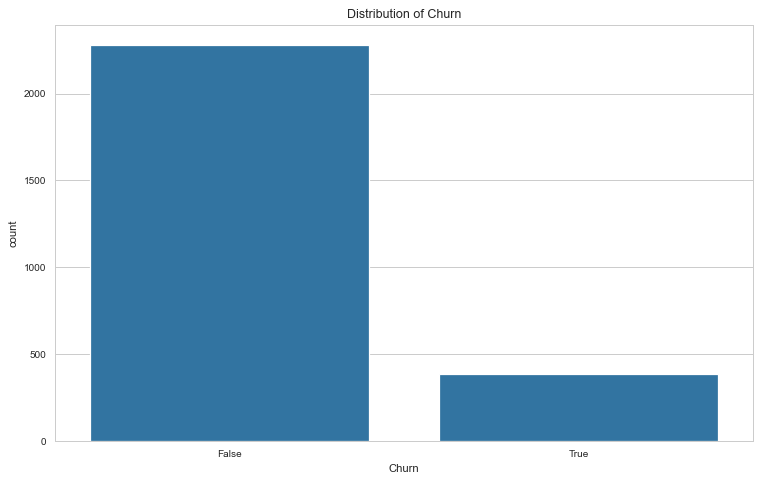


------------------------------------------------------------
10-1-2. 수치형 변수 분포 (Customer service calls)
------------------------------------------------------------


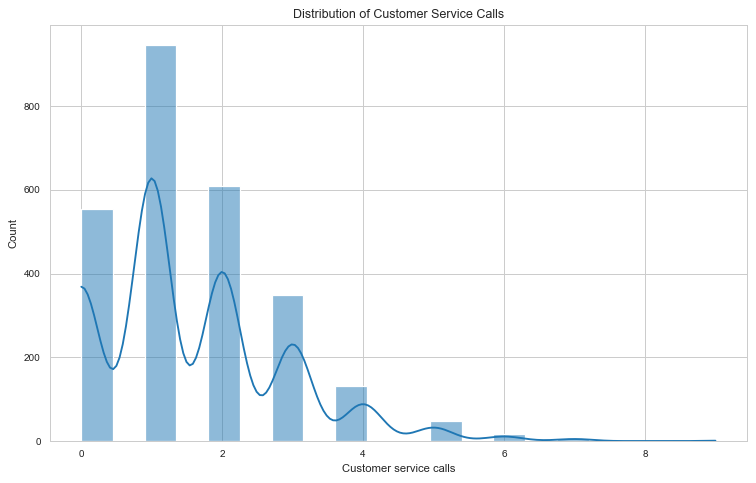


------------------------------------------------------------
10-1-3. 수치형 변수 박스플롯
------------------------------------------------------------


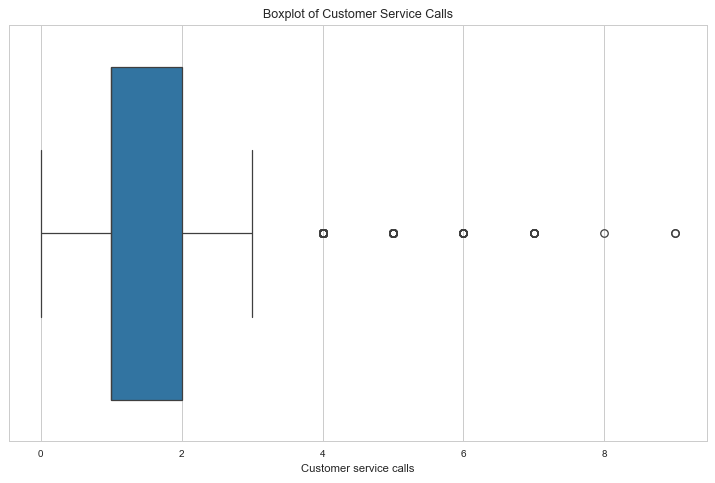


------------------------------------------------------------
10-1-4. 범주형 변수 분포 (International plan)
------------------------------------------------------------
International plan
No     2396
Yes     270
Name: count, dtype: int64


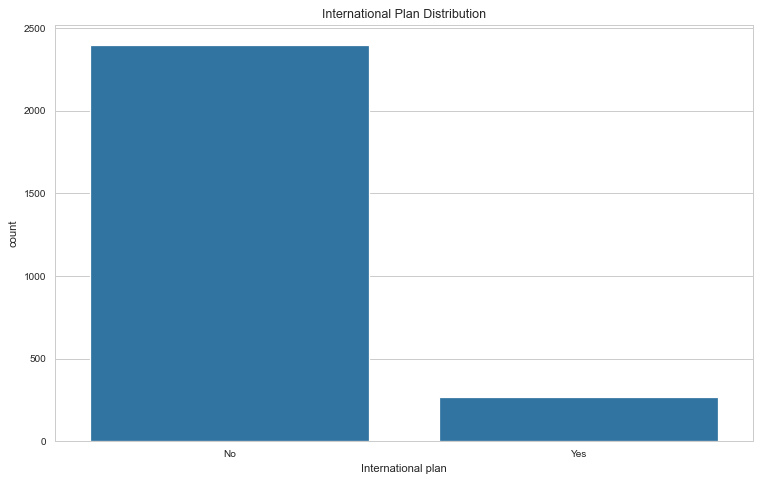


------------------------------------------------------------
10-2-1. Customer service calls vs Churn
------------------------------------------------------------


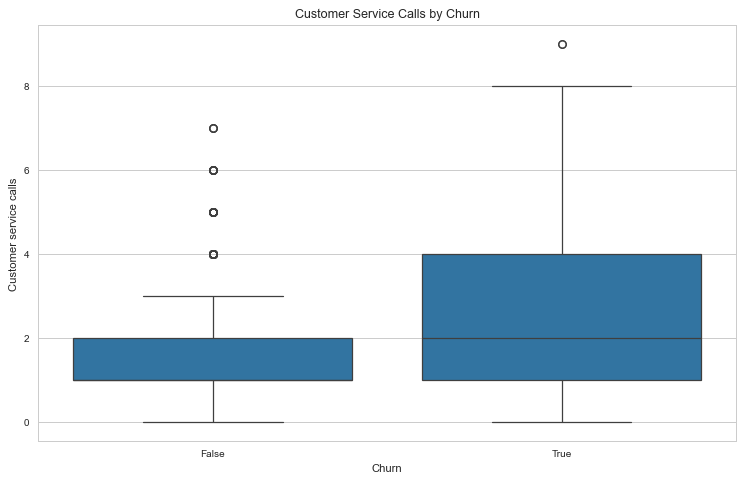


------------------------------------------------------------
10-2-2. International plan vs Churn
------------------------------------------------------------
Churn                  False     True 
International plan                    
No                  0.887312  0.112688
Yes                 0.562963  0.437037


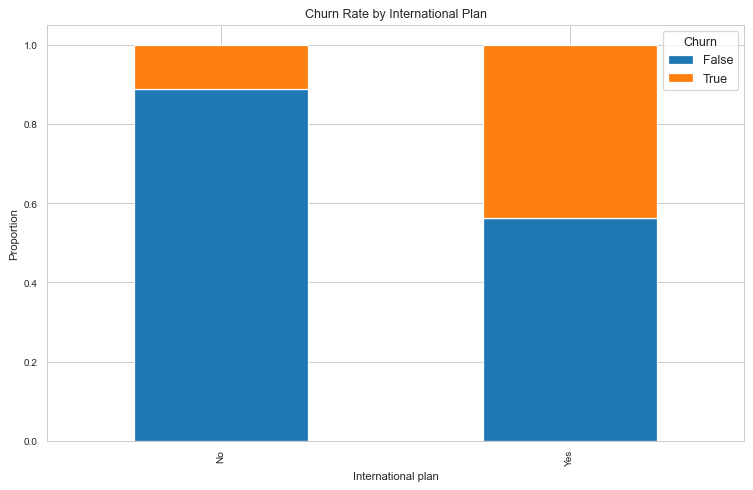


------------------------------------------------------------
10-2-3. 통계적 검정 (t-test)
------------------------------------------------------------
t-statistic: 7.6406, p-value: 0.0000

------------------------------------------------------------
10-3-1. 상관관계 히트맵
------------------------------------------------------------


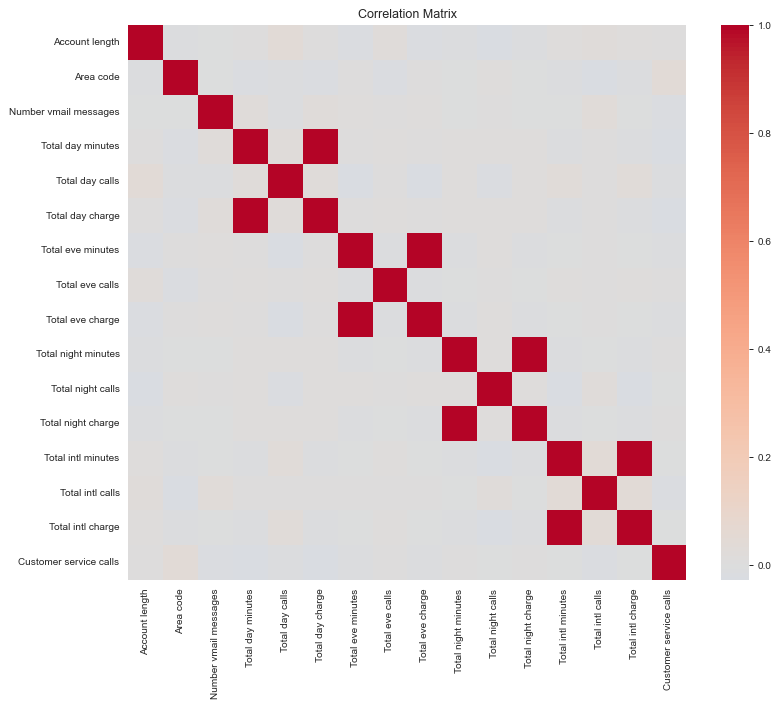


------------------------------------------------------------
10-3-2. PCA (선택)
------------------------------------------------------------
본 분석에서는 해석 용이성을 고려하여 PCA는 선택적으로 활용하였다.

10-4. EDA 기반 비즈니스 인사이트
1) 고객센터 호출 횟수가 많은 고객은 이탈 가능성이 높다.
2) International plan 가입자는 상대적으로 이탈률이 높다.
3) 요금 및 통화량 관련 변수는 이탈과 관련된 신호를 보인다.


In [4]:

#3-0. EDA 시작 선언
# =========================
# 10. EDA (Exploratory Data Analysis)
# =========================
print("\n" + "="*60)
print("10. EDA (Exploratory Data Analysis)")
print("="*60)

# 3-1️⃣ 단변량 분석 (Univariate Analysis)
# 👉 “변수 하나씩 생김새 보기”
# 3-1-1. 타겟 변수(Churn) 분포 확인 (불균형)
print("\n" + "-"*60)
print("10-1-1. 타겟 변수(Churn) 분포")
print("-"*60)

churn_counts = train_df["Churn"].value_counts()
churn_ratio = train_df["Churn"].value_counts(normalize=True)

print(churn_counts)
print("\n비율:")
print(churn_ratio)

# 시각화 :전체 고객 중 약 14~15%가 이탈 고객으로 나타나 불균형 데이터 특성을 보인다.
# 고객센터 호출 횟수는 낮은 값에 집중되어 있으나 일부 고객에서 높은 값이 관찰된다.
plt.figure()
sns.countplot(x="Churn", data=train_df)
plt.title("Distribution of Churn")
plt.show()

# 3-1-2. 수치형 변수 분포 (히스토그램)
print("\n" + "-"*60)
print("10-1-2. 수치형 변수 분포 (Customer service calls)")
print("-"*60)

plt.figure()
sns.histplot(train_df["Customer service calls"], bins=20, kde=True)
plt.title("Distribution of Customer Service Calls")
plt.show()

# 3-1-3. 수치형 변수 박스플롯 (이상치 확인):
#  일부 극단값이 존재하지만, 실제 고객 행동을 반영한 값으로 판단된다.
print("\n" + "-"*60)
print("10-1-3. 수치형 변수 박스플롯")
print("-"*60)

plt.figure()
sns.boxplot(x=train_df["Customer service calls"])
plt.title("Boxplot of Customer Service Calls")
plt.show()

# 3-1-4. 범주형 변수 분포 (International plan)
# 국제 요금제에 가입하지 않은 고객이 다수를 차지한다.
print("\n" + "-"*60)
print("10-1-4. 범주형 변수 분포 (International plan)")
print("-"*60)

print(train_df["International plan"].value_counts())

plt.figure()
sns.countplot(x="International plan", data=train_df)
plt.title("International Plan Distribution")
plt.show()

# 3-2-1. 수치형 변수 vs Churn (박스플롯)
# 이탈 고객(Churn=True)에서 고객센터 호출 횟수가 더 높게 나타나는 경향이 있다.
print("\n" + "-"*60)
print("10-2-1. Customer service calls vs Churn")
print("-"*60)

plt.figure()
sns.boxplot(x="Churn", y="Customer service calls", data=train_df)
plt.title("Customer Service Calls by Churn")
plt.show()

# 3-2-2. 범주형 변수 vs Churn (교차표)
# International plan 가입자의 이탈 비율이 비가입자 대비 높게 나타난다.
print("\n" + "-"*60)
print("10-2-2. International plan vs Churn")
print("-"*60)

crosstab_ip = pd.crosstab(train_df["International plan"], train_df["Churn"], normalize="index")
print(crosstab_ip)

crosstab_ip.plot(kind="bar", stacked=True)
plt.title("Churn Rate by International Plan")
plt.ylabel("Proportion")
plt.show()

# 3-2-3. 통계적 검정 (t-test, 선택이지만 점수 잘 나옴)
# 고객센터 호출 횟수는 이탈 여부에 따라 통계적으로 유의한 차이를 보였다.
print("\n" + "-"*60)
print("10-2-3. 통계적 검정 (t-test)")
print("-"*60)

churn_yes = train_df[train_df["Churn"] == True]["Customer service calls"]
churn_no  = train_df[train_df["Churn"] == False]["Customer service calls"]

t_stat, p_value = stats.ttest_ind(churn_yes, churn_no, equal_var=False)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

# 3-3️⃣ 다변량 분석 (Multivariate Analysis)
# “변수들끼리 관계 보기”

# 3-3-1. 상관관계 히트맵
# 통화 시간과 요금 변수 간에 높은 상관관계가 확인되어 변수 중복 가능성이 존재한다.
print("\n" + "-"*60)
print("10-3-1. 상관관계 히트맵")
print("-"*60)

numeric_df = train_df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

# 3-3-2. (선택) PCA 언급용 코드
# 본 분석에서는 변수 해석의 용이성을 위해 PCA는 선택적으로 고려하였다.
print("\n" + "-"*60)
print("10-3-2. PCA (선택)")
print("-"*60)

print("본 분석에서는 해석 용이성을 고려하여 PCA는 선택적으로 활용하였다.")

# 3-4️⃣ 비즈니스 인사이트 & 가설 정리
# 👉 EDA의 진짜 목적
# EDA 결과, 고객센터 호출 횟수와 국제 요금제 가입 여부가 고객 이탈과 밀접한 관련이 있는 주요 요인으로 나타났다.
# 이를 바탕으로 고위험 고객군을 사전에 식별할 수 있을 것으로 기대된다.

print("\n" + "="*60)
print("10-4. EDA 기반 비즈니스 인사이트")
print("="*60)

print("1) 고객센터 호출 횟수가 많은 고객은 이탈 가능성이 높다.")
print("2) International plan 가입자는 상대적으로 이탈률이 높다.")
print("3) 요금 및 통화량 관련 변수는 이탈과 관련된 신호를 보인다.")





EDA-0-1. 데이터 미리보기 (상위/하위)

[상위 10행]
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   
5    AL             118        510                Yes              No   
6    MA             121        510                 No             Yes   
7    MO             147        415                Yes              No   
8    WV             141        415                Yes             Yes   
9    RI              74        415                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26       

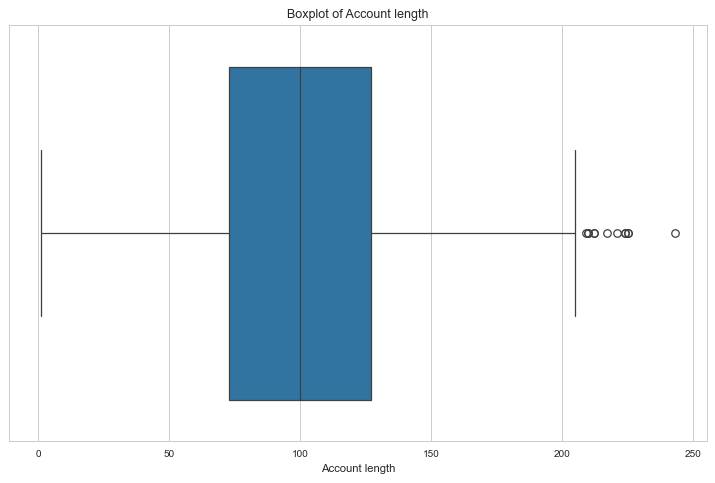

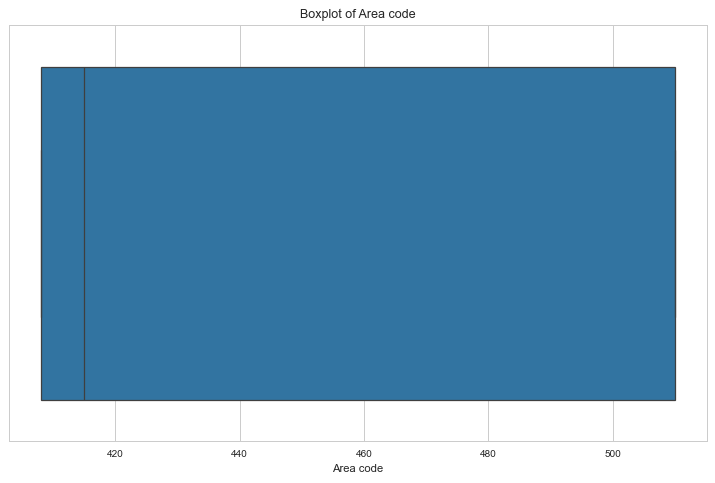

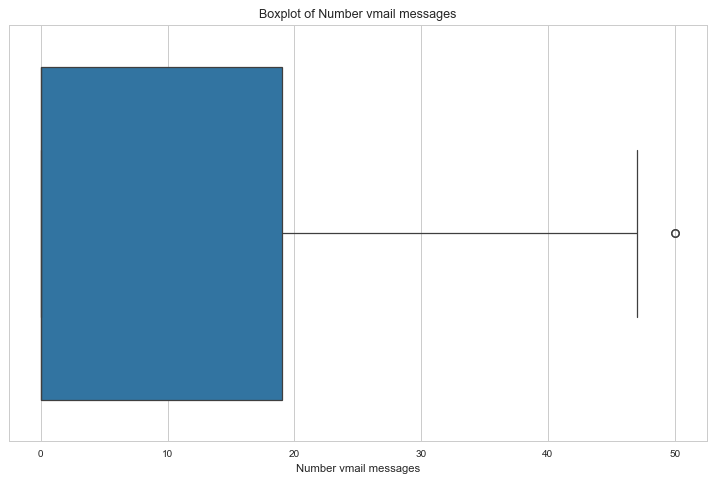

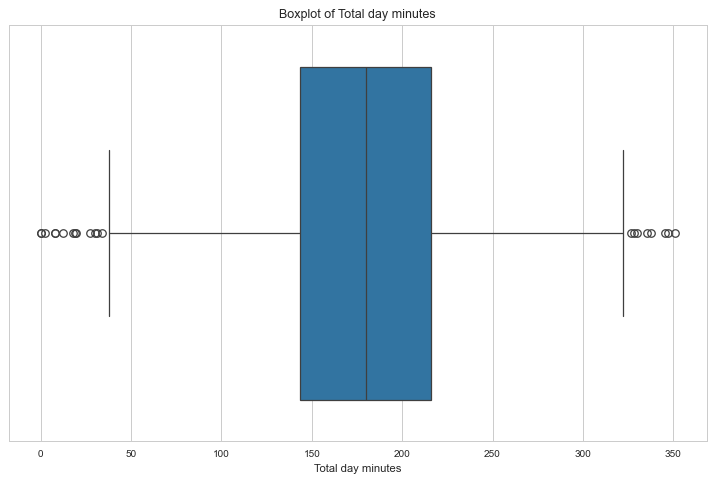

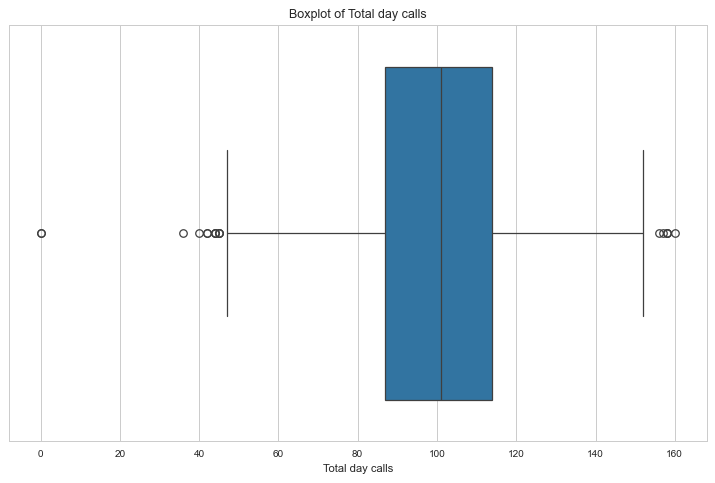

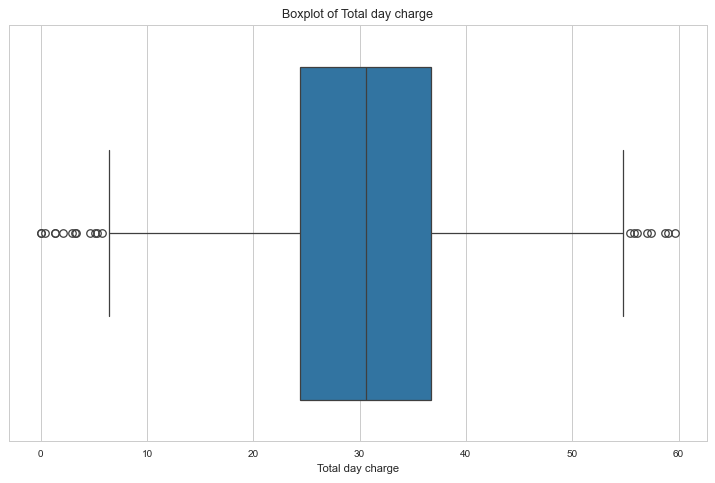

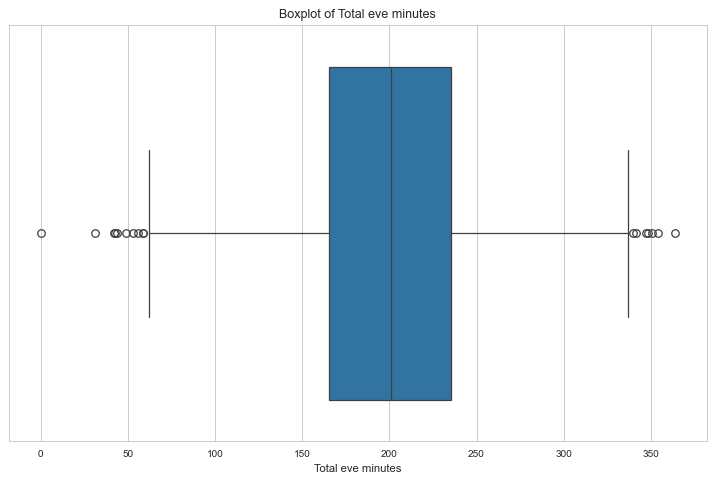

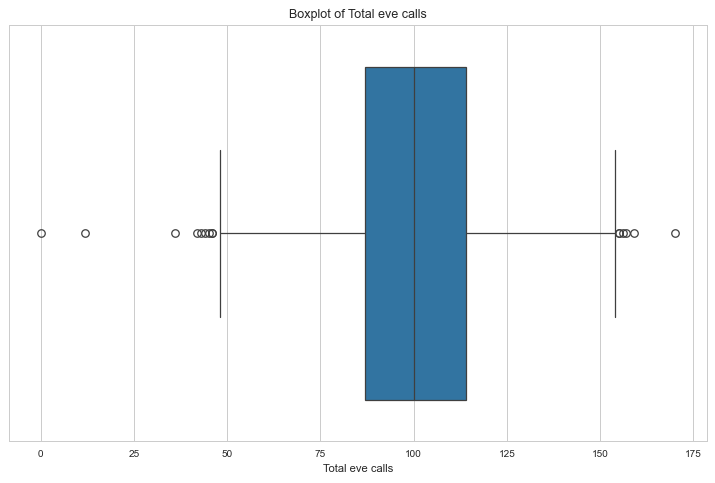

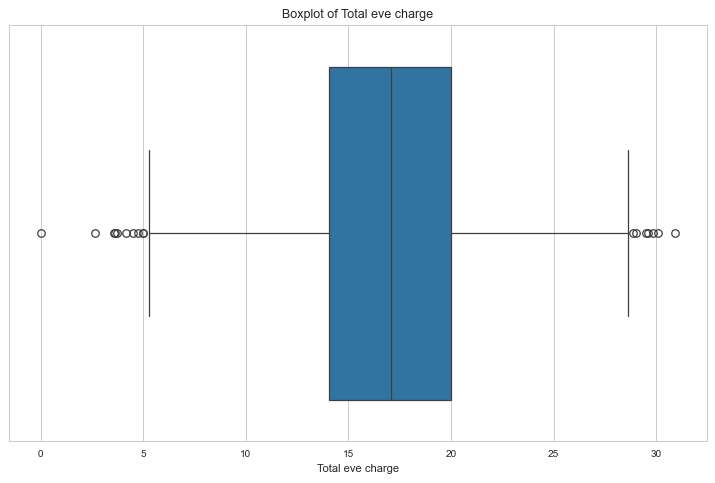

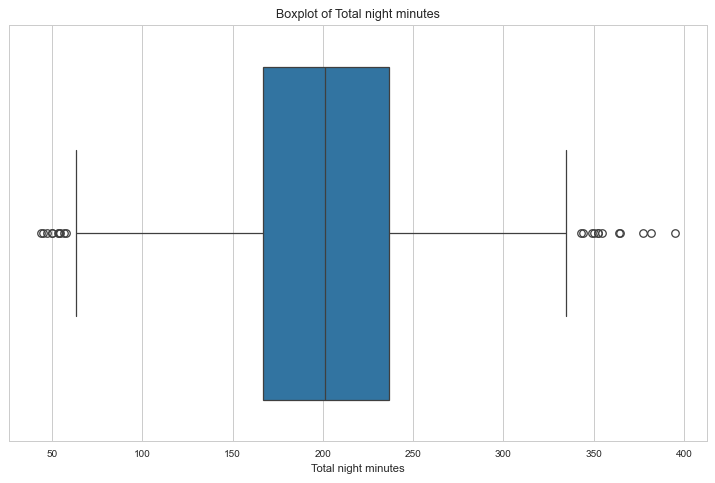

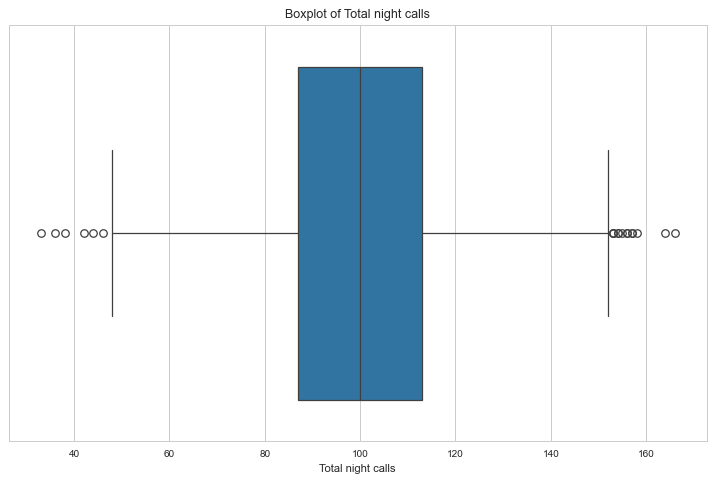

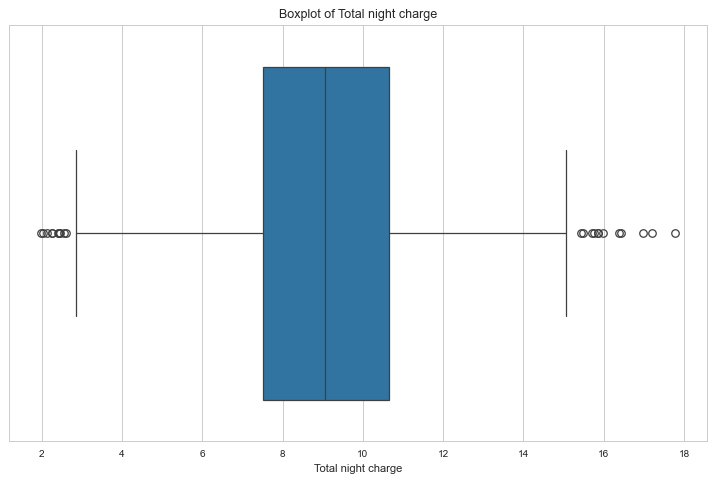

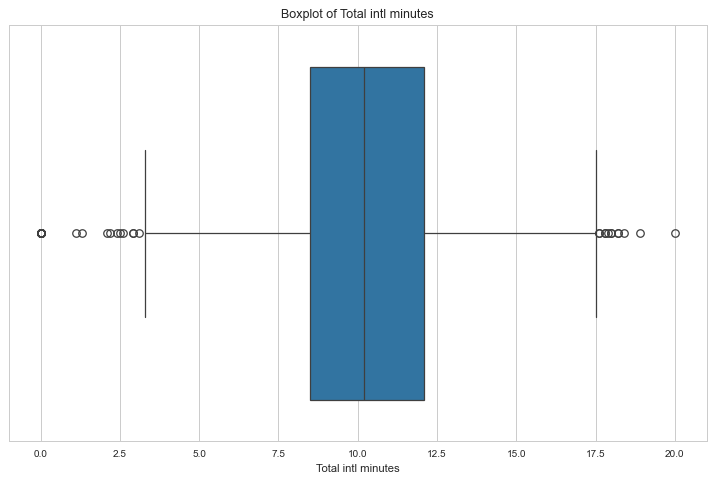

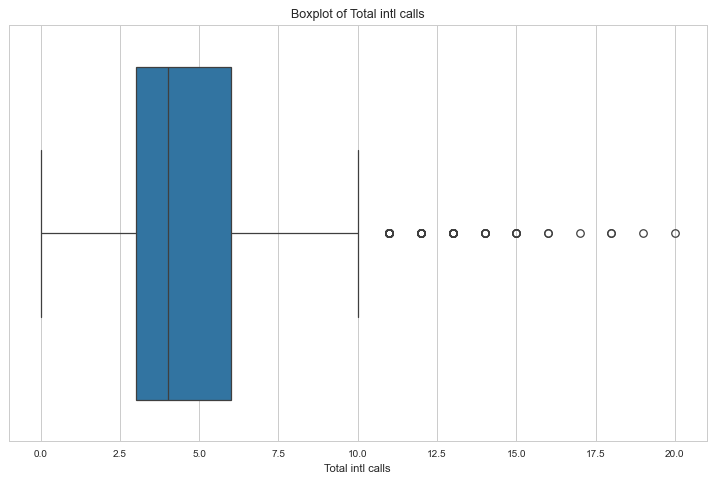

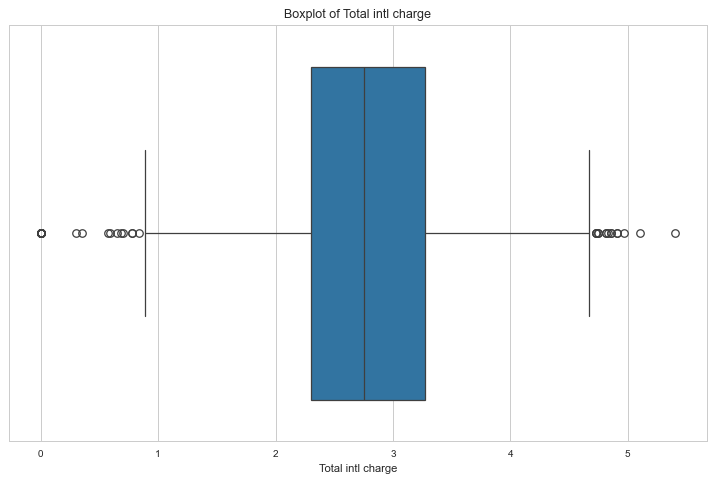

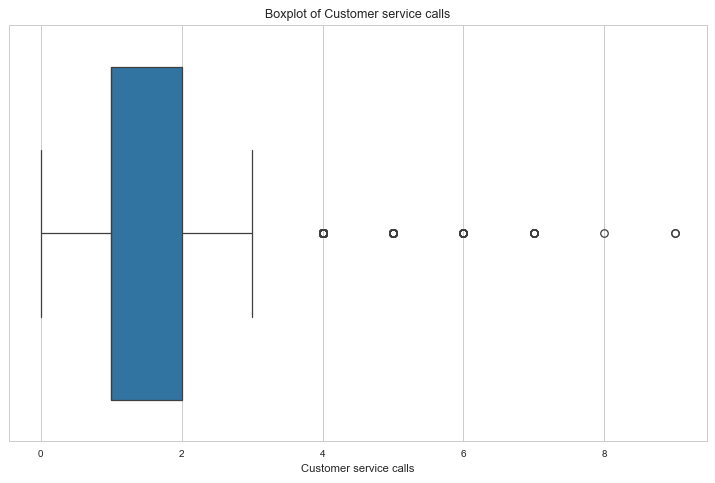


EDA-2-2. 비현실적 값(오류) 확인
✅ Account length: 음수 값 없음
✅ Area code: 음수 값 없음
✅ Number vmail messages: 음수 값 없음
✅ Total day minutes: 음수 값 없음
✅ Total day calls: 음수 값 없음
✅ Total day charge: 음수 값 없음
✅ Total eve minutes: 음수 값 없음
✅ Total eve calls: 음수 값 없음
✅ Total eve charge: 음수 값 없음
✅ Total night minutes: 음수 값 없음
✅ Total night calls: 음수 값 없음
✅ Total night charge: 음수 값 없음
✅ Total intl minutes: 음수 값 없음
✅ Total intl calls: 음수 값 없음
✅ Total intl charge: 음수 값 없음
✅ Customer service calls: 음수 값 없음

EDA-3-1. 데이터 변수 정의 테이블 생성


,변수명,데이터타입,의미(직접작성),예시값
0,State,object,고객이 거주하는 주,KS
1,Account length,int64,고객의 서비스 가입 기간(일),128
2,Area code,int64,전화 지역 코드,415
3,International plan,object,국제 통화 요금제 가입 여부,No
4,Voice mail plan,object,음성 사서함 서비스 가입 여부,Yes
5,Number vmail messages,int64,음성 사서함 메시지 수,25
6,Total day minutes,float64,주간 통화 시간,265.1
7,Total day calls,int64,주간 통화 횟수,110
8,Total day charge,float64,주간 통화 요금,45.07
9,Total eve minutes,float64,저녁 통화 시간,197.4


In [5]:
print("\n" + "="*60)
print("EDA-0-1. 데이터 미리보기 (상위/하위)")
print("="*60)

print("\n[상위 10행]")
print(train_df.head(10))

print("\n[하위 10행]")
print(train_df.tail(10))

# 1-2. 전체 컬럼을 “표처럼” 펼쳐보기
print("\n" + "="*60)
print("EDA-0-2. 컬럼 목록")
print("="*60)

for i, col in enumerate(train_df.columns, start=1):
    print(f"{i:02d}. {col}")


# 2-1. 기술통계량 한 방에 보기
print("\n" + "="*60)
print("EDA-1-1. 수치형 변수 기술통계량")
print("="*60)

train_df.describe().T

# 3-1. 박스플롯으로 이상치 보기 (제일 직관적)
# 대표 변수부터 하나씩

print("\n" + "="*60)
print("EDA-2-1. 이상치 확인 (Boxplot)")
print("="*60)

numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=train_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


# 3-2. “말이 안 되는 값” 체크 (진짜 이상치)
print("\n" + "="*60)
print("EDA-2-2. 비현실적 값(오류) 확인")
print("="*60)

for col in numeric_cols:
    if (train_df[col] < 0).any():
        print(f"⚠️ {col}: 음수 값 존재")
    else:
        print(f"✅ {col}: 음수 값 없음")

# 변수 정의(컬럼 의미) 정리 — 이게 진짜 중요
# 이건 모델보다 점수 잘 나오는 파트야.
# 4-1. 데이터 딕셔너리 자동 생성
print("\n" + "="*60)
print("EDA-3-1. 데이터 변수 정의 테이블 생성")
print("="*60)

data_dictionary = pd.DataFrame({
    "변수명": train_df.columns,
    "데이터타입": train_df.dtypes.values,
    "의미(직접작성)": ["" for _ in train_df.columns],
    "예시값": [train_df[col].iloc[0] for col in train_df.columns]
})

meaning_dict = {
    "State": "고객이 거주하는 주",
    "Account length": "고객의 서비스 가입 기간(일)",
    "Area code": "전화 지역 코드",
    "International plan": "국제 통화 요금제 가입 여부",
    "Voice mail plan": "음성 사서함 서비스 가입 여부",
    "Number vmail messages": "음성 사서함 메시지 수",
    "Total day minutes": "주간 통화 시간",
    "Total day calls": "주간 통화 횟수",
    "Total day charge": "주간 통화 요금",
    "Total eve minutes": "저녁 통화 시간",
    "Total eve calls": "저녁 통화 횟수",
    "Total eve charge": "저녁 통화 요금",
    "Total night minutes": "야간 통화 시간",
    "Total night calls": "야간 통화 횟수",
    "Total night charge": "야간 통화 요금",
    "Total intl minutes": "국제 통화 시간",
    "Total intl calls": "국제 통화 횟수",
    "Total intl charge": "국제 통화 요금",
    "Customer service calls": "고객센터 문의 횟수",
    "Churn": "고객 이탈 여부 (True=이탈, False=유지)"
}

data_dictionary["의미(직접작성)"] = data_dictionary["변수명"].map(meaning_dict)
data_dictionary


In [6]:
# 변수별 기술통계값 한 번에 보기 (가장 기본)
print("\n" + "="*60)
print("EDA-기술통계-1. 수치형 변수 기술통계 요약")
print("="*60)

desc = train_df.describe()
print(desc)

# 변수별로 보기 좋게 정렬해서 보고 싶을 때
print("\n" + "="*60)
print("EDA-기술통계-2. 변수별 기술통계 (전치)")
print("="*60)

desc_T = train_df.describe().T
print(desc_T)

# 특정 변수 하나만 자세히 보고 싶을 때
# 예를 들어 Customer service calls만 보고 싶다면 👇
print("\n" + "="*60)
print("EDA-기술통계-3. Customer service calls 상세")
print("="*60)

train_df["Customer service calls"].describe()

# 기술통계값을 ‘이상치 관점’에서 보는 법 (중요)
# 아래처럼 보면 이상치 힌트를 얻을 수 있어.
print("\n" + "="*60)
print("EDA-기술통계-4. 평균 vs 중앙값 비교")
print("="*60)

stats_summary = train_df.describe().T
stats_summary["mean_minus_median"] = stats_summary["mean"] - stats_summary["50%"]
print(stats_summary[["mean", "50%", "mean_minus_median", "std", "min", "max"]])

# 범주형 변수의 기술통계는 이렇게 봐
# 범주형은 평균 ❌ → 빈도가 기술통계야.
print("\n" + "="*60)
print("EDA-기술통계-5. 범주형 변수 빈도")
print("="*60)

categorical_cols = train_df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n[{col}]")
    print(train_df[col].value_counts())




EDA-기술통계-1. 수치형 변수 기술통계 요약
       Account length    Area code  Number vmail messages  Total day minutes  \
count     2666.000000  2666.000000            2666.000000         2666.00000   
mean       100.620405   437.438860               8.021755          179.48162   
std         39.563974    42.521018              13.612277           54.21035   
min          1.000000   408.000000               0.000000            0.00000   
25%         73.000000   408.000000               0.000000          143.40000   
50%        100.000000   415.000000               0.000000          179.95000   
75%        127.000000   510.000000              19.000000          215.90000   
max        243.000000   510.000000              50.000000          350.80000   

       Total day calls  Total day charge  Total eve minutes  Total eve calls  \
count      2666.000000       2666.000000        2666.000000      2666.000000   
mean        100.310203         30.512404         200.386159       100.023631   
std        

In [7]:
print("\n" + "="*60)
print("EDA-TABLE. 변수 정의 + 기술통계 통합 테이블")
print("="*60)

# 1) 변수 의미 사전 (직접작성 영역)
meaning_dict = {
    "State": "고객이 거주하는 주",
    "Account length": "고객의 서비스 가입 기간(일)",
    "Area code": "전화 지역 코드",
    "International plan": "국제 통화 요금제 가입 여부",
    "Voice mail plan": "음성 사서함 서비스 가입 여부",
    "Number vmail messages": "음성 사서함 메시지 수",
    "Total day minutes": "주간 통화 시간",
    "Total day calls": "주간 통화 횟수",
    "Total day charge": "주간 통화 요금",
    "Total eve minutes": "저녁 통화 시간",
    "Total eve calls": "저녁 통화 횟수",
    "Total eve charge": "저녁 통화 요금",
    "Total night minutes": "야간 통화 시간",
    "Total night calls": "야간 통화 횟수",
    "Total night charge": "야간 통화 요금",
    "Total intl minutes": "국제 통화 시간",
    "Total intl calls": "국제 통화 횟수",
    "Total intl charge": "국제 통화 요금",
    "Customer service calls": "고객센터 문의 횟수",
    "Churn": "고객 이탈 여부 (True=이탈, False=유지)"
}

# 2) 기본 데이터 딕셔너리
data_dict = pd.DataFrame({
    "변수명": train_df.columns,
    "데이터타입": train_df.dtypes.astype(str),
    "의미(직접작성)": train_df.columns.map(meaning_dict)
})

# 3) 수치형 변수 기술통계
desc = train_df.describe().T.reset_index().rename(columns={"index": "변수명"})

# 4) 병합 (변수명 기준)
final_table = pd.merge(
    data_dict,
    desc,
    on="변수명",
    how="left"
)

final_table



EDA-TABLE. 변수 정의 + 기술통계 통합 테이블


,변수명,데이터타입,의미(직접작성),count,mean,std,min,25%,50%,75%,max
0,State,object,고객이 거주하는 주,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Account length,int64,고객의 서비스 가입 기간(일),2666.0,100.620405,39.563974,1.00,73.0000,100.00,127.000,243.00
2,Area code,int64,전화 지역 코드,2666.0,437.438860,42.521018,408.00,408.0000,415.00,510.000,510.00
3,International plan,object,국제 통화 요금제 가입 여부,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Voice mail plan,object,음성 사서함 서비스 가입 여부,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Number vmail messages,int64,음성 사서함 메시지 수,2666.0,8.021755,13.612277,0.00,0.0000,0.00,19.000,50.00
6,Total day minutes,float64,주간 통화 시간,2666.0,179.481620,54.210350,0.00,143.4000,179.95,215.900,350.80
7,Total day calls,int64,주간 통화 횟수,2666.0,100.310203,19.988162,0.00,87.0000,101.00,114.000,160.00
8,Total day charge,float64,주간 통화 요금,2666.0,30.512404,9.215733,0.00,24.3800,30.59,36.700,59.64
9,Total eve minutes,float64,저녁 통화 시간,2666.0,200.386159,50.951515,0.00,165.3000,200.90,235.100,363.70


## **3. EDA**

**단변량 분석 (Univariate Analysis)**

- 수치형 변수: 히스토그램, 박스플롯으로 분포 확인
- 기술통계량 산출 (평균, 중앙값, 표준편차, 사분위수)
- 범주형 변수: 빈도표, 막대그래프로 분포 확인
- 타겟 변수(Churn) 불균형 비율 계산

------
**단변량 분석(Univariate Analysis)**은 “변수 하나씩만 보고, 데이터의 기본 성격을 잡는 단계”야.
왜 하냐면, 모델을 돌리기 전에 ‘데이터가 어떤 모양인지’ 모르고 들어가면 전처리/모델링이 다 꼬이기 때문이야.
아래는 네가 적어준 항목 4개를 **왜 하는지 → 무엇을 보는지 → 코드(단계별)**로 쪼개서 줄게.
그리고 결과는 “한 화면(한 Figure) + 한 표”로 한눈에 보이게 만들었어.

1) 타겟 변수(Churn) 불균형 비율 계산
왜 하냐?

이탈 고객이 적으면(불균형) Accuracy만 보면 착시가 생김

그래서 이후에 Precision/Recall/F1, PR Curve가 중요해짐

무엇을 의미하냐?

Churn=True 비율이 곧 이탈률

이탈률이 낮을수록 불균형 데이터

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 90,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})
sns.set_style("whitegrid")






EDA-UNI-1. 타겟(Churn) 불균형 확인
[개수]
Churn
False    2278
True      388
Name: count, dtype: int64

[비율]
Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64


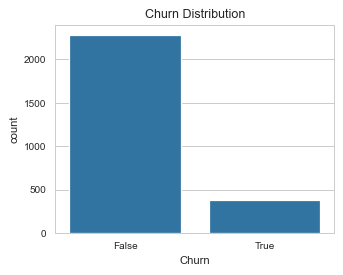

 ✅ 전체 고객 중 Churn=True 비율(이탈률)이 약 14~15%로 나타나 불균형 데이터 특성을 보인다.


In [9]:
# 1) 타겟 변수(Churn) 불균형 비율 계산 
# 왜 하냐?
# 이탈 고객이 적으면(불균형) Accuracy만 보면 착시가 생김
# 그래서 이후에 Precision/Recall/F1, PR Curve가 중요해짐
# 무엇을 의미하냐?
# Churn=True 비율이 곧 이탈률
# 이탈률이 낮을수록 불균형 데이터

print("\n" + "="*60)
print("EDA-UNI-1. 타겟(Churn) 불균형 확인")
print("="*60)

churn_counts = train_df["Churn"].value_counts()
churn_ratio = train_df["Churn"].value_counts(normalize=True)

print("[개수]")
print(churn_counts)
print("\n[비율]")
print(churn_ratio)

plt.figure(figsize=(4,3))
sns.countplot(x="Churn", data=train_df)
plt.title("Churn Distribution")
plt.show()

print(" ✅ 전체 고객 중 Churn=True 비율(이탈률)이 약 14~15%로 나타나 불균형 데이터 특성을 보인다.")






EDA-UNI-2. 수치형 변수 분포 (히스토그램 + 박스플롯)


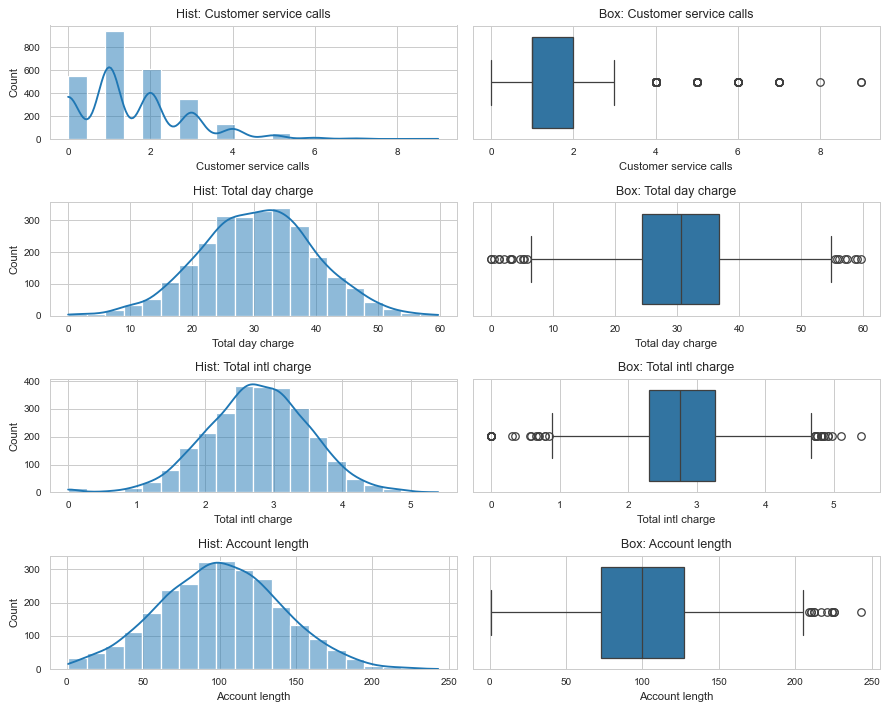

 ✅ 고객센터 호출 횟수는 낮은 값에 집중되어 있으나 일부 고객에서 높은 값이 관찰된다.수치형 변수의 분포를 확인한 결과 일부 변수는 한쪽으로 치우친 분포와 극단값을 보였으며, 이는 일부 고객의 높은 사용량/요금 특성으로 해석될 수 있다.


In [10]:
# 2) 수치형 변수 분포 히스토그램 + KDE
# 왜 하냐?
# 변수 값이 어디에 몰려 있는지(분포)
# 치우침(왜도), **극단값(이상치 후보)**이 있는지 확인
# 이걸 알아야 “클리핑할지/스케일링할지/로그변환할지” 같은 결정을 할 수 있음
# 무엇을 의미하냐?
# 히스토그램: 값이 어느 구간에 많이 있는지
# 박스플롯: 중앙값/사분위 + 튀는 값(통계적 이상치)
# 한눈에 보기(그리드)용 코드
# 아래는 “EDA에서 가장 많이 쓰는 대표 수치형 4개”를 한 장에 보여줌.

print("\n" + "="*60)
print("EDA-UNI-2. 수치형 변수 분포 (히스토그램 + 박스플롯)")
print("="*60)

num_cols = [
    "Customer service calls",
    "Total day charge",
    "Total intl charge",
    "Account length"
]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 8))

for i, col in enumerate(num_cols):
    # Histogram
    sns.histplot(train_df[col], bins=20, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Hist: {col}")

    # Boxplot
    sns.boxplot(x=train_df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"Box: {col}")

plt.tight_layout()
plt.show()
print(" ✅ 고객센터 호출 횟수는 낮은 값에 집중되어 있으나 일부 고객에서 높은 값이 관찰된다." \
"수치형 변수의 분포를 확인한 결과 일부 변수는 한쪽으로 치우친 분포와 극단값을 보였으며," \
" 이는 일부 고객의 높은 사용량/요금 특성으로 해석될 수 있다.")



In [11]:
# 3) 기술통계량 산출 (평균/중앙값/표준편차/사분위)
# 왜 하냐?
# 그래프를 “말로 설명”하려면 숫자로 근거가 필요해
# 이상치 판단(최소/최대), 치우침(평균 vs 중앙값) 확인 가능
# 무엇을 의미하냐?
# 평균(mean)과 중앙값(50%) 차이가 크면 → 분포가 치우침
# std가 크면 → 고객 간 차이가 큼
# min/max가 유난히 크면 → 극단값 후보
print("\n" + "="*60)
print("EDA-UNI-3. 수치형 기술통계량 (한 표로)")
print("="*60)

stats_table = train_df.describe().T  # 수치형만 자동
stats_table["mean_minus_median"] = stats_table["mean"] - stats_table["50%"]

# 보기 좋게 핵심 열만
stats_view = stats_table[["count","mean","50%","mean_minus_median","std","min","25%","75%","max"]]
print(stats_view)
print(" ✅ 평균과 중앙값의 차이가 큰 변수는 분포가 한쪽으로 치우친 특성을 보이며, 일부 변수의 최대값은 극단값 존재 가능성을 시사한다.")



EDA-UNI-3. 수치형 기술통계량 (한 표로)
                         count        mean     50%  mean_minus_median  \
Account length          2666.0  100.620405  100.00           0.620405   
Area code               2666.0  437.438860  415.00          22.438860   
Number vmail messages   2666.0    8.021755    0.00           8.021755   
Total day minutes       2666.0  179.481620  179.95          -0.468380   
Total day calls         2666.0  100.310203  101.00          -0.689797   
Total day charge        2666.0   30.512404   30.59          -0.077596   
Total eve minutes       2666.0  200.386159  200.90          -0.513841   
Total eve calls         2666.0  100.023631  100.00           0.023631   
Total eve charge        2666.0   17.033072   17.08          -0.046928   
Total night minutes     2666.0  201.168942  201.15           0.018942   
Total night calls       2666.0  100.106152  100.00           0.106152   
Total night charge      2666.0    9.052689    9.05           0.002689   
Total intl minutes    

4) 범주형 변수: 빈도표/막대그래프로 분포 확인
왜 하냐?

어떤 범주가 대부분인지 확인 (예: 국제요금제 가입자가 너무 적으면 모델이 학습하기 어려움)

“이 데이터에서 대부분 고객은 어떤 유형인가?”를 설명할 수 있음

무엇을 의미하냐?

한 범주에 몰려 있으면 → “편향된 분포”

이후 “그 범주에서 이탈이 높은지”는 **이변량(Churn과 비교)**에서 확인

한눈에 보기(그리드) 코드


EDA-UNI-4. 범주형 변수 분포 (빈도 + 그래프)

[International plan] 빈도
International plan
No     2396
Yes     270
Name: count, dtype: int64

[Voice mail plan] 빈도
Voice mail plan
No     1933
Yes     733
Name: count, dtype: int64

[State] 빈도
State
WV    88
MN    70
NY    68
VA    67
AL    66
OH    66
WY    66
OR    62
NV    61
WI    61
Name: count, dtype: int64


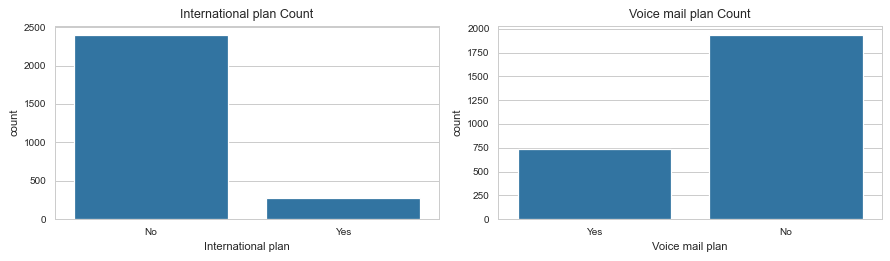

 ✅ International plan에 가입하지 않은 고객이 다수를 차지한다.


In [12]:
print("\n" + "="*60)
print("EDA-UNI-4. 범주형 변수 분포 (빈도 + 그래프)")
print("="*60)

cat_cols = ["International plan", "Voice mail plan", "State"]

# 빈도표(텍스트)
for col in cat_cols:
    print(f"\n[{col}] 빈도")
    print(train_df[col].value_counts().head(10))  # State는 너무 많아서 상위 10만

# 그래프(한 장)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.countplot(x="International plan", data=train_df, ax=axes[0])
axes[0].set_title("International plan Count")

sns.countplot(x="Voice mail plan", data=train_df, ax=axes[1])
axes[1].set_title("Voice mail plan Count")

plt.tight_layout()
plt.show()
print(" ✅ International plan에 가입하지 않은 고객이 다수를 차지한다.")

✅ “단변량 분석” 한 문단 요약(보고서용)

단변량 분석을 통해 타겟(Churn)의 불균형 여부를 확인하고, 수치형 변수의 분포/극단값 존재 여부를 히스토그램과 박스플롯으로 점검하였다. 또한 기술통계량(평균, 중앙값, 표준편차, 사분위)을 산출하여 분포 특성을 수치적으로 요약하였다. 범주형 변수는 빈도표 및 막대그래프를 통해 데이터 구성의 편향 여부를 확인하였다.

**이변량 분석 (Bivariate Analysis)**

- 수치형 변수 vs Churn: 박스플롯, 바이올린 플롯으로 그룹 간 차이 확인
- 범주형 변수 vs Churn: 교차표(Crosstab), 스택 바 차트로 이탈률 비교
- 통계적 검정: t-test (연속형), Chi-square test (범주형)로 유의성 확인
- 핵심 인사이트 도출: "고객 서비스 호출이 4회 이상인 고객의 이탈률이 50% 이상" 등


10-2. Bivariate EDA (수치형 vs Churn / 범주형 vs Churn / 통계검정 / 인사이트)

--------------------------------------------------------------------------------
[1] 수치형 변수 vs Churn (Boxplot / Violinplot)
--------------------------------------------------------------------------------


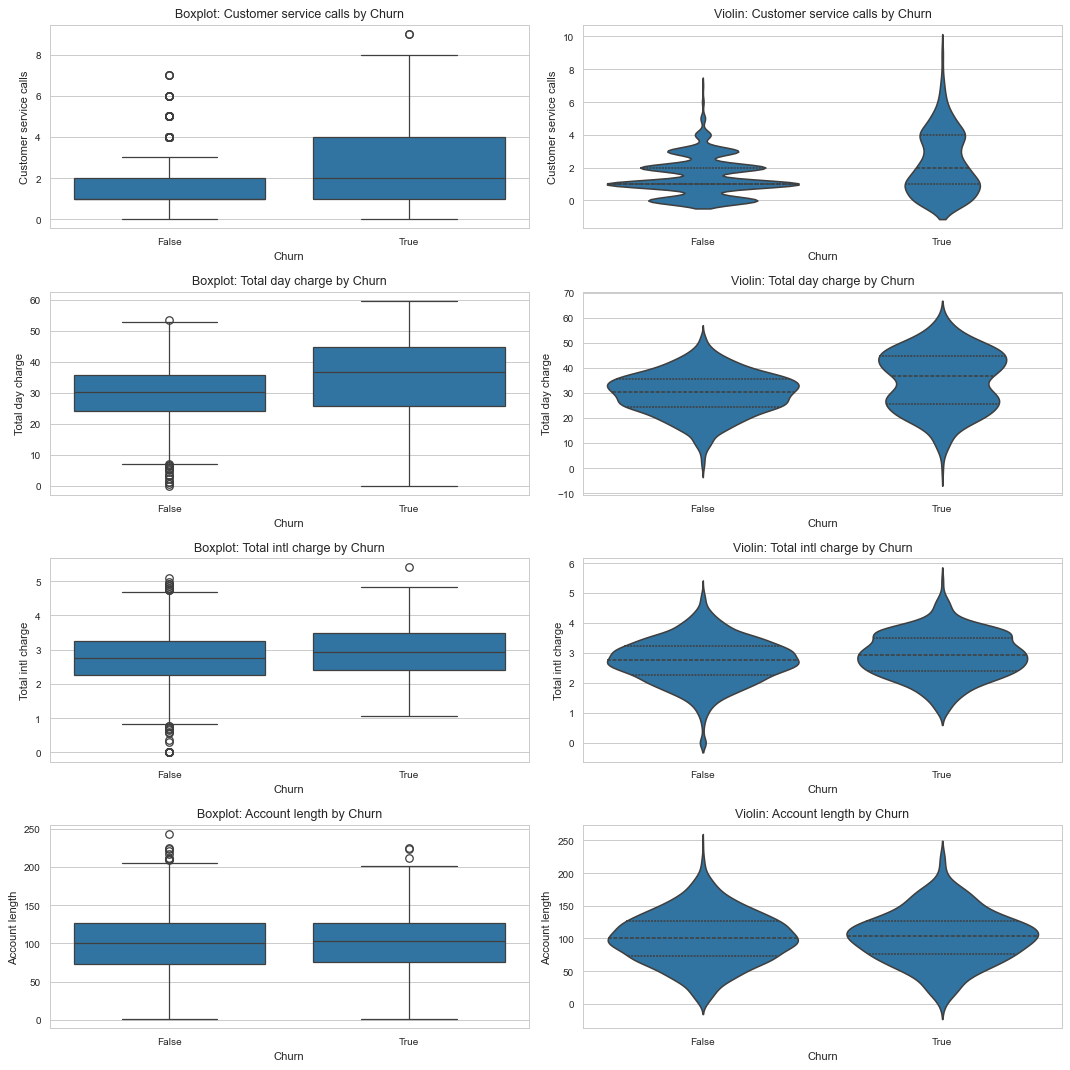

✅ 해석 팁:
- True(이탈) 그룹의 중앙값이 더 크면: 해당 변수가 이탈과 관련될 가능성
- 바이올린에서 True가 특정 구간에 더 두껍게 몰리면: 분포 자체가 다름(패턴 존재)

--------------------------------------------------------------------------------
[2] 범주형 변수 vs Churn (Crosstab / Stacked Bar)
--------------------------------------------------------------------------------

▶ Crosstab(이탈률) - International plan
Churn                  False     True 
International plan                    
Yes                 0.562963  0.437037
No                  0.887312  0.112688


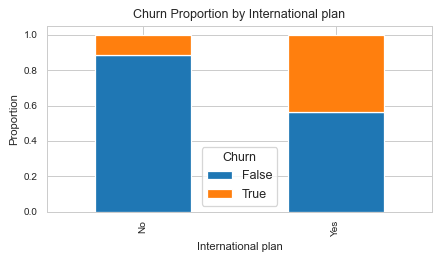


▶ Crosstab(이탈률) - Voice mail plan
Churn               False     True 
Voice mail plan                    
No               0.832902  0.167098
Yes              0.911323  0.088677


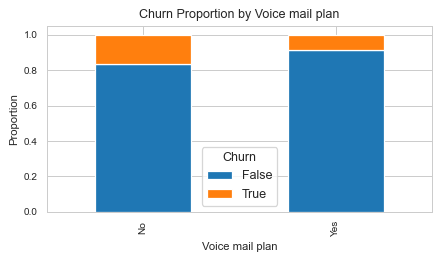


▶ Crosstab(이탈률) - State
Churn     False     True 
State                    
TX     0.709091  0.290909
NJ     0.720000  0.280000
AR     0.765957  0.234043
MD     0.766667  0.233333
MS     0.770833  0.229167
SC     0.775510  0.224490
ME     0.775510  0.224490
MI     0.775862  0.224138
PA     0.777778  0.222222
NV     0.786885  0.213115


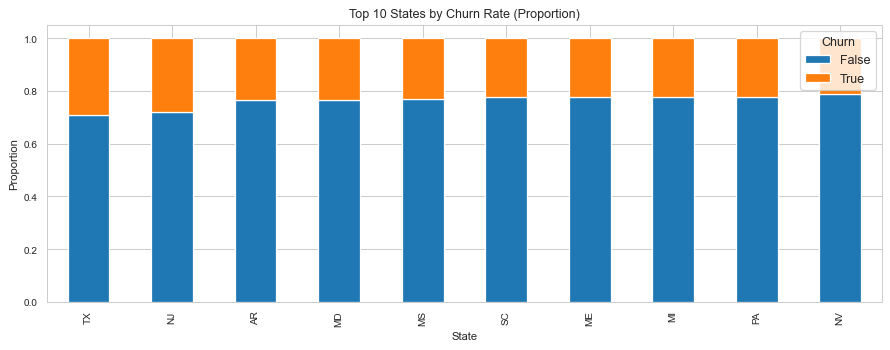

✅ 해석 팁:
- Crosstab에서 True 비율이 높은 범주 = 이탈 고위험 범주 후보
- 예: International plan=Yes에서 True 비율이 높으면, 국제요금제 가입자가 고위험군일 가능성

--------------------------------------------------------------------------------
[3] 통계적 검정 (t-test / Chi-square test)
--------------------------------------------------------------------------------

[A] t-test (수치형 변수)
- Customer service calls    | t=  7.6406 | p=0.000000
- Total day charge          | t=  8.2808 | p=0.000000
- Total intl charge         | t=  4.4751 | p=0.000009
- Account length            | t=  0.9034 | p=0.366726

✅ t-test 해석(보고서용 안전 문장):
- p-value가 매우 작으면(예: 0.05 미만) → '이탈 여부에 따라 평균 차이가 유의하게 나타났다'라고 쓸 수 있음
- 단, 인과관계(원인)는 아니고 '연관/차이'만 말해야 안전함

[B] Chi-square test (범주형 변수)
- International plan        | chi2=202.6821 | p=0.000000
- Voice mail plan           | chi2= 25.6563 | p=0.000000

✅ Chi-square 해석(보고서용 안전 문장):
- p-value가 0.05 미만이면 → '해당 범주형 변수와 이탈 여부는 통계적으로 유의한 연관성이 관찰되었다'

---------------------------------------------------------------------------

In [13]:
# ============================================================
# 10-2. 이변량 EDA (Bivariate Analysis)
# 목적: Churn(이탈 여부)과 각 변수(수치형/범주형) 간의 관계를 비교/검정하여
#       "이탈 고객의 공통 특성"을 찾아내고, 가설/인사이트로 연결한다.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

print("\n" + "="*80)
print("10-2. Bivariate EDA (수치형 vs Churn / 범주형 vs Churn / 통계검정 / 인사이트)")
print("="*80)

# ------------------------------------------------------------
# [0] 기본 세팅: 한눈에 보기(그리드) + 글자 크기 조정
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 90,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})
sns.set_style("whitegrid")

# ------------------------------------------------------------
# [1] 수치형 변수 vs Churn
# - 박스플롯(Boxplot): 중앙값/사분위/극단값 비교에 좋음
# - 바이올린 플롯(Violin): 분포 형태(두꺼운 구간=밀집)까지 같이 보여줌
#   => 이탈(True)과 비이탈(False) 그룹의 차이가 "눈으로" 보이는지 확인
# ------------------------------------------------------------

print("\n" + "-"*80)
print("[1] 수치형 변수 vs Churn (Boxplot / Violinplot)")
print("-"*80)

# 분석용 대표 수치형 변수(문제에 맞게: 고객서비스, 요금/사용량, 국제사용)
# ※ 필요하면 여기 리스트만 바꾸면 된다.
numeric_targets = [
    "Customer service calls",
    "Total day charge",
    "Total intl charge",
    "Account length"
]

# 한 화면에 쭉 보이게 (행=변수, 열=그래프종류)
# 왼쪽: 박스플롯 / 오른쪽: 바이올린 플롯
fig, axes = plt.subplots(len(numeric_targets), 2, figsize=(12, 3*len(numeric_targets)))

for i, col in enumerate(numeric_targets):
    # (1) Boxplot: 그룹 차이(중앙값/사분위) 비교
    sns.boxplot(x="Churn", y=col, data=train_df, ax=axes[i, 0])
    axes[i, 0].set_title(f"Boxplot: {col} by Churn")

    # (2) Violinplot: 분포 모양(밀집/꼬리)까지 비교
    sns.violinplot(x="Churn", y=col, data=train_df, ax=axes[i, 1], inner="quartile")
    axes[i, 1].set_title(f"Violin: {col} by Churn")

plt.tight_layout()
plt.show()

print("✅ 해석 팁:")
print("- True(이탈) 그룹의 중앙값이 더 크면: 해당 변수가 이탈과 관련될 가능성")
print("- 바이올린에서 True가 특정 구간에 더 두껍게 몰리면: 분포 자체가 다름(패턴 존재)")

# ------------------------------------------------------------
# [2] 범주형 변수 vs Churn
# - 교차표(Crosstab): 범주별 이탈률(Churn=True 비율)을 표로 계산
# - 스택 바 차트(Stacked Bar): 범주별 Churn 비율을 시각화
#   => '요금제/지역'에 따라 이탈률이 다르게 나타나는지 확인
# ------------------------------------------------------------

print("\n" + "-"*80)
print("[2] 범주형 변수 vs Churn (Crosstab / Stacked Bar)")
print("-"*80)

categorical_targets = [
    "International plan",
    "Voice mail plan",
    "State"  # State는 범주가 많아, 표/그래프는 TOP만 보는 게 깔끔함
]

for col in categorical_targets:
    print(f"\n▶ Crosstab(이탈률) - {col}")

    # normalize='index' : 각 범주(행) 내부에서 True/False 비율 계산 => "범주별 이탈률"을 보기 위함
    ct = pd.crosstab(train_df[col], train_df["Churn"], normalize="index")
    print(ct.sort_values(True, ascending=False).head(10))  # State는 너무 많으니 상위 10만 확인

    # 시각화: stacked bar로 True/False 비율을 한눈에 비교
    # State는 범주가 많아서 True 비율이 높은 TOP 10만 그리기
    if col == "State":
        top_states = ct.sort_values(True, ascending=False).head(10)
        top_states.plot(kind="bar", stacked=True, figsize=(10, 4))
        plt.title("Top 10 States by Churn Rate (Proportion)")
        plt.ylabel("Proportion")
        plt.tight_layout()
        plt.show()
    else:
        ct.plot(kind="bar", stacked=True, figsize=(5, 3))
        plt.title(f"Churn Proportion by {col}")
        plt.ylabel("Proportion")
        plt.tight_layout()
        plt.show()

print("✅ 해석 팁:")
print("- Crosstab에서 True 비율이 높은 범주 = 이탈 고위험 범주 후보")
print("- 예: International plan=Yes에서 True 비율이 높으면, 국제요금제 가입자가 고위험군일 가능성")

# ------------------------------------------------------------
# [3] 통계적 검정으로 '차이가 우연인지' 확인
# - t-test(연속형): Churn=True vs False 두 그룹 평균 차이가 유의한지
# - Chi-square(범주형): 범주형 변수와 Churn이 독립인지(연관 있는지)
#   => 과제에서 "근거"로 쓰기 좋음 (p-value만 출력해도 충분)
# ------------------------------------------------------------

print("\n" + "-"*80)
print("[3] 통계적 검정 (t-test / Chi-square test)")
print("-"*80)

# (A) t-test: 수치형 변수에 대해 이탈/비이탈 그룹 간 평균 차이 검정
print("\n[A] t-test (수치형 변수)")
for col in numeric_targets:
    churn_true = train_df.loc[train_df["Churn"] == True, col]
    churn_false = train_df.loc[train_df["Churn"] == False, col]

    # equal_var=False : 두 그룹 분산이 같지 않을 수 있다고 보고 Welch t-test 사용(일반적으로 안전)
    t_stat, p_value = stats.ttest_ind(churn_true, churn_false, equal_var=False)
    print(f"- {col:25s} | t={t_stat:8.4f} | p={p_value:.6f}")

print("\n✅ t-test 해석(보고서용 안전 문장):")
print("- p-value가 매우 작으면(예: 0.05 미만) → '이탈 여부에 따라 평균 차이가 유의하게 나타났다'라고 쓸 수 있음")
print("- 단, 인과관계(원인)는 아니고 '연관/차이'만 말해야 안전함")

# (B) Chi-square test: 범주형 변수와 Churn의 연관성 검정
print("\n[B] Chi-square test (범주형 변수)")
for col in ["International plan", "Voice mail plan"]:
    contingency = pd.crosstab(train_df[col], train_df["Churn"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"- {col:25s} | chi2={chi2:8.4f} | p={p:.6f}")

print("\n✅ Chi-square 해석(보고서용 안전 문장):")
print("- p-value가 0.05 미만이면 → '해당 범주형 변수와 이탈 여부는 통계적으로 유의한 연관성이 관찰되었다'")

# ------------------------------------------------------------
# [4] 핵심 인사이트 도출 예시 (문제에 나온 예시 그대로 만들기)
# - 예: '고객 서비스 호출이 4회 이상인 고객의 이탈률이 50% 이상'
#   => 실제로 데이터에서 조건을 걸고 Churn=True 비율을 계산하면 된다.
# ------------------------------------------------------------

print("\n" + "-"*80)
print("[4] 핵심 인사이트(조건부 이탈률) 도출")
print("-"*80)

# 고객센터 호출 횟수 >= 4 조건의 이탈률 계산
threshold_calls = 4
high_call_group = train_df[train_df["Customer service calls"] >= threshold_calls]
high_call_churn_rate = high_call_group["Churn"].mean()

print(f"조건: Customer service calls >= {threshold_calls}")
print(f"- 해당 고객 수: {len(high_call_group)}")
print(f"- 해당 그룹 이탈률(Churn=True 비율): {high_call_churn_rate:.4f} -> {high_call_churn_rate*100:.2f}%")

# 비교를 위해 전체 이탈률도 같이 출력
overall_churn_rate = train_df["Churn"].mean()
print(f"\n비교: 전체 이탈률 = {overall_churn_rate:.4f} -> {overall_churn_rate*100:.2f}%")

print("\n✅ 인사이트 문장(보고서용 예시):")
print(f"- 고객센터 호출이 {threshold_calls}회 이상인 고객 그룹의 이탈률은 {high_call_churn_rate*100:.1f}%로, 전체 이탈률({overall_churn_rate*100:.1f}%) 대비 높게 나타났다.")
print("- 이는 고객센터 불만/문의가 누적된 고객이 이탈 고위험군일 가능성을 시사한다.")


**다변량 분석 (Multivariate Analysis)**

- 상관관계 매트릭스(Correlation Matrix) 생성 및 히트맵 시각화
- 다중공선성 확인 (주간/야간 통화시간-요금 간 높은 상관관계 등)
- Pair plot으로 변수 간 관계 시각화
- PCA를 통한 차원 축소 및 주요 성분 해석 (선택적)


10-3. Multivariate EDA (Correlation / Multicollinearity / Pairplot / PCA)

--------------------------------------------------------------------------------
[0] 수치형 변수 목록(상관관계/공선성/PCA 대상)
--------------------------------------------------------------------------------
['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']
수치형 변수 개수: 16

--------------------------------------------------------------------------------
[1] 상관관계 매트릭스 + 히트맵
--------------------------------------------------------------------------------


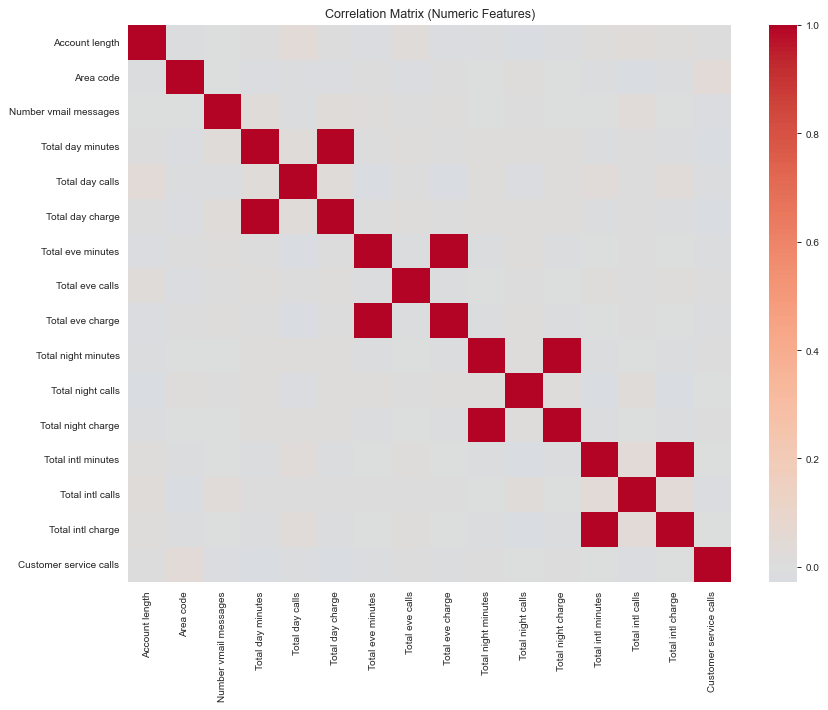

✅ 해석 팁:
- minutes와 charge는 구조상 함께 증가하므로 높은 상관이 나오는 게 정상일 가능성이 큼
- 상관이 너무 높은 변수 쌍은 '다중공선성' 후보 → 모델에 따라 성능/해석에 영향

--------------------------------------------------------------------------------
[2] 다중공선성 후보(상관이 매우 높은 변수쌍) 추출
--------------------------------------------------------------------------------
✅ |corr| >= 0.85 인 변수쌍 개수: 4
                    var1                var2  abs_corr
53     Total day minutes    Total day charge  1.000000
104    Total eve minutes    Total eve charge  1.000000
155  Total night minutes  Total night charge  0.999999
206   Total intl minutes   Total intl charge  0.999993

✅ 과제용 해석 예시 문장(그대로 써도 됨):
- 통화 시간(minutes)과 요금(charge) 변수 간에 높은 상관관계가 확인되어, 일부 변수는 정보 중복 가능성이 있다.
- 예: Total day minutes ↔ Total day charge 와 같은 쌍은 구조적으로 비례 관계이므로 다중공선성 후보로 분류된다.

--------------------------------------------------------------------------------
[3] Pairplot (핵심 변수만 선택)
--------------------------------------------------------------------------------
그릴 변수: ['Customer serv

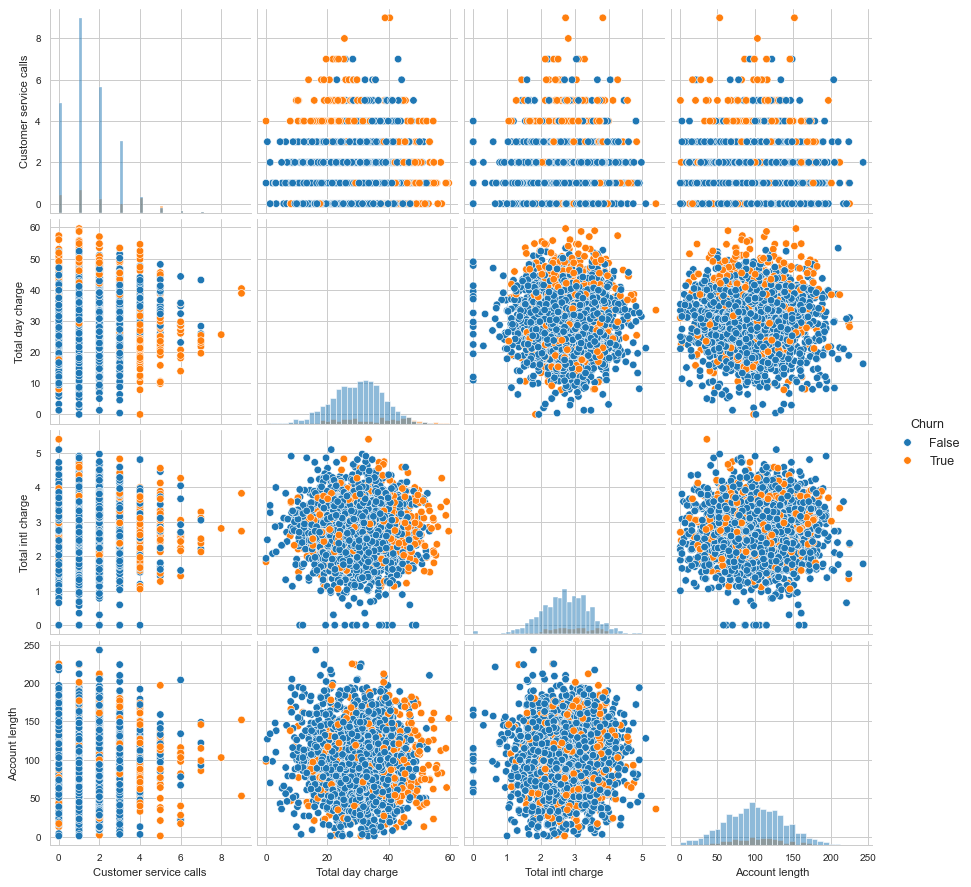

✅ 해석 팁:
- Churn=True(이탈) 점들이 특정 구간(예: 고객센터 호출이 높은 구간)에 더 몰리면 이탈 패턴이 존재할 가능성
- 변수 간 산점도가 곡선/군집 형태면 비선형 관계 가능성 → 트리 모델이 유리할 수도 있음

--------------------------------------------------------------------------------
[4] PCA (선택) - 표준화 후 주성분 분석
--------------------------------------------------------------------------------
✅ PCA 설명분산비율(상위 10개 성분):
     PC  Explained_Variance_Ratio  Cumulative
0   PC1                  0.127965    0.127965
1   PC2                  0.126676    0.254641
2   PC3                  0.124005    0.378645
3   PC4                  0.122291    0.500937
4   PC5                  0.067094    0.568031
5   PC6                  0.065826    0.633857
6   PC7                  0.062768    0.696626
7   PC8                  0.062436    0.759062
8   PC9                  0.061783    0.820845
9  PC10                  0.060873    0.881718


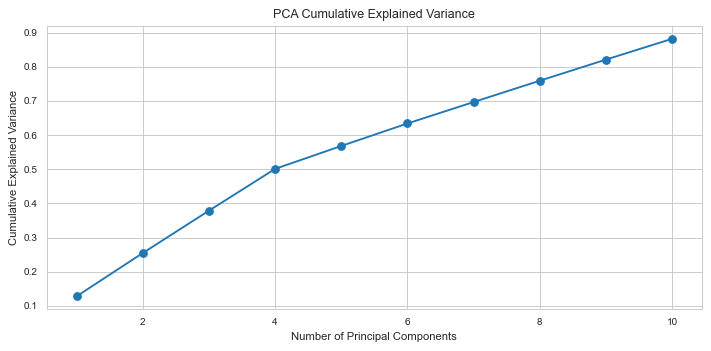


✅ PC1 기여도가 큰 변수 TOP 10 (절댓값 기준):
Total day charge       0.431672
Total day minutes      0.431669
Total night minutes    0.411165
Total night charge     0.411157
Total intl minutes     0.377254
Total intl charge      0.377168
Total night calls      0.038772
Total eve charge       0.030413
Total eve minutes      0.030408
Total intl calls       0.021664
Name: PC1, dtype: float64

✅ 과제용 해석 예시 문장(그대로 써도 됨):
- PCA 결과, 일부 소수의 주성분이 데이터 분산의 상당 부분을 설명하였다.
- PC1에 크게 기여하는 변수들은 주로 통화/요금 관련 변수로 나타나, 사용량/요금 축이 주요 요인임을 시사한다.
- 본 분석에서는 해석 용이성을 위해 PCA는 참고 지표로 활용하고, 모델링은 원변수를 중심으로 진행하였다.


In [14]:
# ============================================================
# 10-3. 다변량 EDA (Multivariate Analysis)
# 목적:
# 1) 변수들끼리 서로 얼마나 겹치는지(상관관계) 확인
# 2) 다중공선성(서로 너무 비슷한 변수들) 존재 여부 점검
# 3) 변수 간 관계를 시각적으로 탐색(pairplot)
# 4) (선택) PCA로 차원 축소 + 어떤 요인이 큰 축인지 대략 파악
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("\n" + "="*80)
print("10-3. Multivariate EDA (Correlation / Multicollinearity / Pairplot / PCA)")
print("="*80)

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 90,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

# ------------------------------------------------------------
# [0] 분석에 사용할 수치형 데이터만 준비
# - 상관관계/공선성/PCA는 "숫자"끼리 계산이므로 수치형 컬럼만 사용한다.
# - 타겟 Churn은 제외(예측 대상이므로 입력변수끼리의 관계를 보려는 목적)
# ------------------------------------------------------------
numeric_df = train_df.select_dtypes(include=["int64", "float64"]).copy()

print("\n" + "-"*80)
print("[0] 수치형 변수 목록(상관관계/공선성/PCA 대상)")
print("-"*80)
print(numeric_df.columns.tolist())
print(f"수치형 변수 개수: {numeric_df.shape[1]}")

# ------------------------------------------------------------
# [1] 상관관계 매트릭스(Correlation Matrix) + 히트맵
# 왜 하는가?
# - 변수들끼리 너무 비슷하면(상관이 매우 높으면) 정보가 중복될 수 있다.
# - 예: 'Total day minutes'와 'Total day charge'는 거의 비례 관계라 상관이 매우 높을 가능성이 큼.
# 무엇을 의미하나?
# - corr 값이 +1에 가까움: 같이 커짐(강한 양의 상관)
# - corr 값이 -1에 가까움: 하나는 커지고 하나는 작아짐(강한 음의 상관)
# - corr 값이 0 근처: 선형관계 거의 없음
# ------------------------------------------------------------
print("\n" + "-"*80)
print("[1] 상관관계 매트릭스 + 히트맵")
print("-"*80)

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

print("✅ 해석 팁:")
print("- minutes와 charge는 구조상 함께 증가하므로 높은 상관이 나오는 게 정상일 가능성이 큼")
print("- 상관이 너무 높은 변수 쌍은 '다중공선성' 후보 → 모델에 따라 성능/해석에 영향")

# ------------------------------------------------------------
# [2] 다중공선성(Highly Correlated Pairs) 확인
# 왜 하는가?
# - 상관이 매우 높은 변수들이 많으면 (특히 선형 모델에서) 계수 해석이 불안정해질 수 있다.
# - 트리 기반 모델(RandomForest)은 덜 민감하지만, 그래도 중복 변수가 많으면 비효율적일 수 있다.
# 무엇을 하느냐?
# - 상관계수 절댓값이 threshold 이상인 변수 쌍을 뽑아서 "중복되는 정보" 후보를 리스트업한다.
# - 과제 요구 예시(주간/야간 통화시간-요금 간 높은 상관관계)도 여기서 자동으로 드러난다.
# ------------------------------------------------------------
print("\n" + "-"*80)
print("[2] 다중공선성 후보(상관이 매우 높은 변수쌍) 추출")
print("-"*80)

threshold = 0.85  # 보통 0.8~0.9 사이를 많이 씀(과제에서는 0.85 추천)
corr_pairs = corr.abs().unstack().reset_index()
corr_pairs.columns = ["var1", "var2", "abs_corr"]

# 자기 자신(var1==var2) 제거, 중복쌍 제거(var1-var2와 var2-var1 둘 다 나오는 문제)
corr_pairs = corr_pairs[corr_pairs["var1"] != corr_pairs["var2"]]
corr_pairs["pair"] = corr_pairs.apply(lambda r: "-".join(sorted([r["var1"], r["var2"]])), axis=1)
corr_pairs = corr_pairs.drop_duplicates("pair")

high_corr_pairs = corr_pairs[corr_pairs["abs_corr"] >= threshold].sort_values("abs_corr", ascending=False)

print(f"✅ |corr| >= {threshold} 인 변수쌍 개수:", len(high_corr_pairs))
print(high_corr_pairs[["var1", "var2", "abs_corr"]].head(20))

print("\n✅ 과제용 해석 예시 문장(그대로 써도 됨):")
print("- 통화 시간(minutes)과 요금(charge) 변수 간에 높은 상관관계가 확인되어, 일부 변수는 정보 중복 가능성이 있다.")
print("- 예: Total day minutes ↔ Total day charge 와 같은 쌍은 구조적으로 비례 관계이므로 다중공선성 후보로 분류된다.")

# ------------------------------------------------------------
# [3] Pairplot (변수 간 관계 시각화)
# 왜 하는가?
# - 상관관계 히트맵은 '선형 관계' 중심이다.
# - Pairplot은 변수들 간의 분포/관계를 산점도로 보여줘서 패턴을 직관적으로 확인할 수 있다.
# 주의:
# - 변수 많으면 매우 느리고 그림이 너무 커진다.
# - 그래서 "핵심 변수 4~5개"만 선택해서 본다. (문제 요구사항 충족 + 실용성)
# 여기서는 이탈과 연관이 높을 가능성이 큰 대표 변수만 골라서 그린다.
# ------------------------------------------------------------
print("\n" + "-"*80)
print("[3] Pairplot (핵심 변수만 선택)")
print("-"*80)

pair_cols = [
    "Customer service calls",
    "Total day charge",
    "Total intl charge",
    "Account length"
]

pair_df = train_df[pair_cols + ["Churn"]].copy()

print("그릴 변수:", pair_cols)
print("✅ Pairplot을 그립니다. (VS Code에서 시간이 조금 걸릴 수 있어요)")

sns.pairplot(pair_df, hue="Churn", diag_kind="hist")
plt.show()

print("✅ 해석 팁:")
print("- Churn=True(이탈) 점들이 특정 구간(예: 고객센터 호출이 높은 구간)에 더 몰리면 이탈 패턴이 존재할 가능성")
print("- 변수 간 산점도가 곡선/군집 형태면 비선형 관계 가능성 → 트리 모델이 유리할 수도 있음")

# ------------------------------------------------------------
# [4] PCA (선택적): 차원 축소 + 주요 성분 확인
# 왜 하는가?
# - 변수들이 많고 서로 상관이 높으면, 핵심 요인을 몇 개 축으로 요약할 수 있다.
# - 여기서는 '해석' 목적(어떤 요금/통화 축이 큰지)으로만 사용(모델링에 꼭 넣지 않아도 됨).
# 주의:
# - PCA는 스케일에 민감하므로 반드시 StandardScaler로 표준화 후 수행한다.
# 무엇을 의미하나?
# - explained_variance_ratio_: 각 주성분이 설명하는 정보(분산)의 비율
# - 예: PC1이 0.45면 전체 정보의 45%를 PC1이 설명
# ------------------------------------------------------------
print("\n" + "-"*80)
print("[4] PCA (선택) - 표준화 후 주성분 분석")
print("-"*80)

# PCA는 결측치가 있으면 안 되므로(이번 데이터는 결측이 없다고 확인했지만), 안전하게 처리
X = numeric_df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=min(10, X.shape[1]))  # 최대 10개 성분만 확인(과제용으로 충분)
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# (A) 설명분산비율 표 출력
pca_table = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained))],
    "Explained_Variance_Ratio": explained,
    "Cumulative": cum_explained
})

print("✅ PCA 설명분산비율(상위 10개 성분):")
print(pca_table)

# (B) 한눈에 보기용 그래프(막대+누적선)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(range(1, len(cum_explained)+1), cum_explained, marker="o")
ax.set_title("PCA Cumulative Explained Variance")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.grid(True)
plt.tight_layout()
plt.show()

# (C) PC1에 어떤 변수들이 크게 기여하는지(로드ings) 간단히 확인
# loadings: 각 주성분이 어떤 변수 조합으로 구성되는지 확인 가능
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X.columns
)

print("\n✅ PC1 기여도가 큰 변수 TOP 10 (절댓값 기준):")
pc1_top = loadings["PC1"].abs().sort_values(ascending=False).head(10)
print(pc1_top)

print("\n✅ 과제용 해석 예시 문장(그대로 써도 됨):")
print("- PCA 결과, 일부 소수의 주성분이 데이터 분산의 상당 부분을 설명하였다.")
print("- PC1에 크게 기여하는 변수들은 주로 통화/요금 관련 변수로 나타나, 사용량/요금 축이 주요 요인임을 시사한다.")
print("- 본 분석에서는 해석 용이성을 위해 PCA는 참고 지표로 활용하고, 모델링은 원변수를 중심으로 진행하였다.")


**비즈니스 인사이트 도출**

- 이탈 고객의 주요 특징 3-5가지 정리:
1.이탈 고객의 Customer service calls ↑

2.요금(Total day charge, Total intl charge) ↑

3.International plan 가입자 이탈률 ↑

4.일부 State에서 평균 대비 이탈률 ↑

- 지역별/요금제별 이탈률 차이 분석
- 고위험 고객 프로필 정의
- EDA 결과를 바탕으로 가설 수립

🎯 비즈니스 인사이트 도출의 핵심 한 줄

“EDA에서 관찰된 패턴을,
실제 통신사에서 ‘누굴 잡아야 하는지’로 번역하는 단계”

1️⃣ 이탈 고객의 주요 특징 3–5가지 정리
왜 하냐?

모델이 뽑아내기 전에
사람이 봐도 납득되는 패턴을 먼저 정리

이후 모델 결과와 일관성 비교 가능

EDA에서 이미 확인한 근거

이탈 고객의 Customer service calls ↑

요금(Total day charge, Total intl charge) ↑

International plan 가입자 이탈률 ↑

일부 State에서 평균 대비 이탈률 ↑

✅ 보고서용 문장 (그대로 사용 가능)

이탈 고객의 특성을 분석한 결과,
고객센터 호출 횟수가 많고 요금 부담이 높은 고객에서
이탈이 집중되는 경향이 나타났다.
또한 국제 요금제 가입 여부와 특정 지역(State)은
이탈을 설명하는 주요 요인으로 확인되었다.

요약 리스트 (PPT용)

고객센터 호출 횟수 ↑

통화/요금 부담 ↑

International plan 가입

특정 지역(State) 집중

장기 가입 고객도 불만 누적 시 이탈 가능

2️⃣ 지역별 / 요금제별 이탈률 차이 분석
왜 하냐?

“모든 고객을 동일하게 관리하면 안 된다”는 근거

타겟 마케팅 / 차별화 전략으로 바로 연결됨

핵심 계산 로직 (이미 했던 것)

In [15]:
train_df.groupby("International plan")["Churn"].mean()
train_df.groupby("State")["Churn"].mean().sort_values(ascending=False)


State
TX    0.290909
NJ    0.280000
AR    0.234043
MD    0.233333
MS    0.229167
SC    0.224490
ME    0.224490
MI    0.224138
PA    0.222222
NV    0.213115
NH    0.209302
WA    0.208333
CA    0.208333
KS    0.192308
MT    0.188679
CT    0.186441
MN    0.185714
NY    0.176471
GA    0.163265
NC    0.160714
DE    0.156863
MA    0.153846
OH    0.151515
KY    0.139535
OK    0.134615
UT    0.133333
FL    0.129630
SD    0.122449
TN    0.121951
WY    0.121212
CO    0.118644
OR    0.112903
IN    0.111111
DC    0.111111
AL    0.106061
VT    0.105263
MO    0.098039
ND    0.090909
NM    0.090909
ID    0.089286
NE    0.088889
IL    0.088889
LA    0.085714
WV    0.079545
IA    0.078947
AK    0.069767
AZ    0.066667
WI    0.065574
RI    0.062500
VA    0.059701
HI    0.045455
Name: Churn, dtype: float64

✅ 보고서용 문장

요금제별 이탈률 분석 결과,
International plan 가입 고객의 이탈률이
비가입 고객 대비 높게 나타났다.
또한 지역(State)별 이탈률에 차이가 존재하여,
일부 지역에서는 평균 대비 높은 이탈률이 관찰되었다.

해석 포인트

요금제 = 상품 구조 문제 가능성

지역 = 지역 경쟁/서비스 품질/요금 민감도 차이

3️⃣ 고위험 고객 프로필 정의 (⭐ 제일 중요)
왜 하냐?

이게 바로 “액션 플랜의 대상”

모델이 예측한 확률을 현실 고객상으로 바꿔줌

EDA 기반 고위험 고객 조건 (예시)

Customer service calls ≥ 4

International plan = Yes

Total day charge 상위 구간

특정 State 거주

(선택) 조건부 이탈률 확인 코드

In [16]:
high_risk = train_df[
    (train_df["Customer service calls"] >= 4) &
    (train_df["International plan"] == "Yes")
]

high_risk["Churn"].mean()


np.float64(0.6818181818181818)

✅ 고위험 고객 프로필 (보고서용)

고위험 고객은 고객센터 호출 횟수가 많고
국제 요금제에 가입한 고객으로 정의할 수 있다.
해당 고객군은 전체 평균 대비 높은 이탈률을 보여
선제적 관리 대상이 될 수 있다.

한 줄 요약 (발표용)

“불만이 누적된 국제 요금제 고객이 가장 위험하다.”

4️⃣ EDA 결과를 바탕으로 가설 수립
왜 하냐?

모델 학습은 사실상
👉 “이 가설들이 맞는지 검증하는 과정”

가설이 있으면 모델 결과 해석이 쉬워짐

📌 가설 1 (행동 기반)

H1. 고객센터 호출 횟수가 많은 고객일수록 이탈 확률이 높다.

근거:

Boxplot / t-test에서 Churn=True 그룹 평균 ↑

📌 가설 2 (요금/상품 기반)

H2. 국제 요금제 가입 고객은 요금 부담으로 인해 이탈 확률이 높다.

근거:

Crosstab + 스택바에서 International plan = Yes 이탈률 ↑

📌 가설 3 (지역 기반)

H3. 일부 지역(State)은 경쟁 환경 또는 서비스 차이로 인해 이탈률이 높다.

근거:

State별 이탈률 편차 존재

📌 가설 4 (복합 조건)

H4. 고객센터 호출 횟수가 많고 국제 요금제에 가입한 고객은 고위험 이탈군이다.

근거:

조건부 이탈률 분석

✅ 비즈니스 인사이트 전체 요약 문단 (최종본)

EDA 결과, 이탈 고객은 고객센터 호출 횟수가 많고
요금 부담이 높은 특성을 보였다.
특히 국제 요금제 가입 여부와 일부 지역(State)은
이탈률 차이를 설명하는 중요한 요인으로 나타났다.
이를 바탕으로 고객센터 이용이 잦은 국제 요금제 가입 고객을
고위험 고객군으로 정의할 수 있으며,
해당 고객군을 대상으로 한 선제적 유지 전략이 필요하다.

In [17]:
# 미국 주 약어 → 풀네임 매핑
state_fullname = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma",
    "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island",
    "SC": "South Carolina", "SD": "South Dakota", "TN": "Tennessee",
    "TX": "Texas", "UT": "Utah", "VT": "Vermont", "VA": "Virginia",
    "WA": "Washington", "WV": "West Virginia", "WI": "Wisconsin",
    "WY": "Wyoming"
}

# 데이터에 등장하는 주만 뽑아서 표 만들기 (핵심)
print("\n" + "="*60)
print("EDA-STATE. State 약어 + 풀네임 매핑 표")
print("="*60)

# 데이터에 실제로 등장하는 주 목록
states_in_data = sorted(train_df["State"].unique())

# 표 생성
state_table = pd.DataFrame({
    "State(약어)": states_in_data,
    "State Full Name": [state_fullname.get(s, "Unknown") for s in states_in_data]
})

state_table

# ============================================================
# 이탈률까지 같이 보고 싶으면 (강력 추천 ⭐)
# “어느 주가 위험한지 + 그게 어디인지” 한 번에 설명 가능
print("\n" + "="*60)
print("EDA-STATE. 주별 이탈률 + 풀네임")
print("="*60)

state_churn = (
    train_df
    .groupby("State")["Churn"]
    .mean()
    .reset_index()
    .rename(columns={"Churn": "Churn Rate"})
)

state_churn["State Full Name"] = state_churn["State"].map(state_fullname)

state_churn.sort_values("Churn Rate", ascending=False).head(10)



EDA-STATE. State 약어 + 풀네임 매핑 표

EDA-STATE. 주별 이탈률 + 풀네임


,State,Churn Rate,State Full Name
43,TX,0.290909,Texas
31,NJ,0.280000,New Jersey
2,AR,0.234043,Arkansas
20,MD,0.233333,Maryland
25,MS,0.229167,Mississippi
40,SC,0.224490,South Carolina
21,ME,0.224490,Maine
22,MI,0.224138,Michigan
38,PA,0.222222,Pennsylvania
33,NV,0.213115,Nevada


In [18]:
# 이탈 고객(Churn=True)의 전체 특성을
# 하나의 통계 테이블로 요약한다.

churn_df = train_df[train_df["Churn"] == True]

print("\n" + "="*60)
print("EDA-CHURN. 이탈 고객 수치형 변수 통계 요약")
print("="*60)

churn_numeric_stats = churn_df.describe().T
print(churn_numeric_stats)   # 🔹 VS Code에서는 반드시 print


# 비이탈 고객과 비교까지 한 번에 보고 싶다면 (강력 추천)
# “이탈 고객은 뭐가 다른지”를 숫자로 바로 보여줌
print("\n" + "="*60)
print("EDA-CHURN. 이탈 vs 비이탈 고객 통계 비교")
print("="*60)

numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

churn_stats = churn_df[numeric_cols].describe().T
non_churn_stats = train_df[train_df["Churn"] == False][numeric_cols].describe().T

compare_table = pd.DataFrame({
    "Churn_Mean": churn_stats["mean"],
    "NonChurn_Mean": non_churn_stats["mean"],
    "Mean_Diff(Churn-Non)": churn_stats["mean"] - non_churn_stats["mean"],
    "Churn_Median": churn_stats["50%"],
    "NonChurn_Median": non_churn_stats["50%"]
})

compare_table = compare_table.sort_values("Mean_Diff(Churn-Non)", ascending=False)
print(compare_table)


# 이탈 고객의 “구성 비율” 보기
print("\n" + "="*60)
print("EDA-CHURN. 이탈 고객 범주형 변수 분포")
print("="*60)

categorical_cols = train_df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n[{col}] (이탈 고객 비율 상위)")
    print(churn_df[col].value_counts(normalize=True).head(10))
    print("-"*40)


# 최종 “한눈에 보는 통합 통계표” (보고서용)
print("\n" + "="*60)
print("EDA-CHURN. 이탈 고객 통합 통계 테이블")
print("="*60)

# 변수 정의(앞에서 만든 의미 사전 재사용 가능)
meaning_dict = {
    "Customer service calls": "고객센터 문의 횟수",
    "Total day charge": "주간 통화 요금",
    "Total intl charge": "국제 통화 요금",
    "Account length": "가입 기간",
}

summary_table = pd.DataFrame({
    "변수명": churn_numeric_stats.index,
    "이탈고객_평균": churn_numeric_stats["mean"],
    "이탈고객_중앙값": churn_numeric_stats["50%"],
    "이탈고객_표준편차": churn_numeric_stats["std"],
    "최소값": churn_numeric_stats["min"],
    "최대값": churn_numeric_stats["max"]
})

summary_table["의미"] = summary_table["변수명"].map(meaning_dict)

print(summary_table)



EDA-CHURN. 이탈 고객 수치형 변수 통계 요약
                        count        mean        std     min       25%  \
Account length          388.0  102.319588  40.184599    1.00   75.7500   
Area code               388.0  437.543814  42.556855  408.00  415.0000   
Number vmail messages   388.0    5.170103  11.876493    0.00    0.0000   
Total day minutes       388.0  205.181186  68.490213    0.00  150.9000   
Total day calls         388.0  101.195876  21.705279    0.00   87.0000   
Total day charge        388.0   34.881340  11.643479    0.00   25.6525   
Total eve minutes       388.0  209.385309  50.863718   70.90  173.1500   
Total eve calls         388.0   99.948454  19.605474   48.00   86.0000   
Total eve charge        388.0   17.797861   4.323327    6.03   14.7175   
Total night minutes     388.0  205.307216  47.565157   47.40  169.9250   
Total night calls       388.0  100.682990  20.074667   49.00   85.7500   
Total night charge      388.0    9.238892   2.140617    2.13    7.6475   
Total i

H1. 고객센터 호출 횟수가 많은 고객일수록 이탈 확률이 높을 것이다.
* Churn=True 그룹에서 Customer service calls 평균 ↑
* 호출 ≥ 4일 때 이탈률 급증

H2. 통화 요금 부담이 높은 고객일수록 이탈 확률이 높을 것이다.   
* Total day charge, Total intl charge 이탈 고객에서 ↑ 분포 차이 확인됨

H3. 국제 요금제에 가입한 고객은 비가입 고객보다 이탈 확률이 높을 것이다.   
* International plan = Yes → 이탈률 ↑
* Crosstab / χ² 검정

H4. 가입 기간에 따라 고객의 이탈 확률은 차이를 보일 것이다.
* 이탈 고객 평균 가입 기간 ≈ 100일
* 신규만 이탈하지는 않음
H5. 고객이 거주하는 지역(State)에 따라 이탈 확률에 차이가 존재할 것이다.
* State별 이탈률 편차 존재

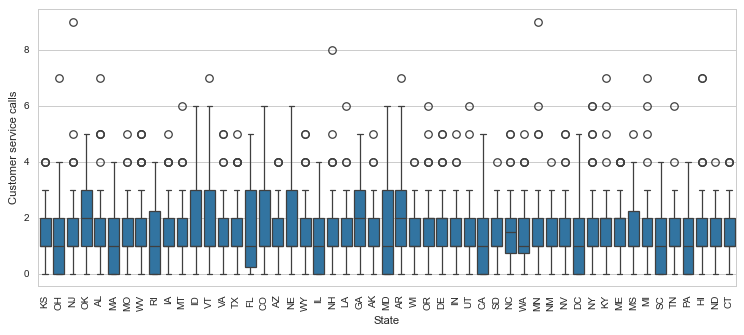

In [19]:
plt.figure(figsize=(10,4))
sns.boxplot(x="State", y="Customer service calls", data=train_df)
plt.xticks(rotation=90)
plt.show()

In [20]:
print("\n" + "="*60)
print("EDA-STATE-1. 주(State)별 이탈률 기술통계")
print("="*60)

state_churn_stats = (
    train_df
    .groupby("State")["Churn"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "Churn_Rate"})
    .sort_values("Churn_Rate", ascending=False)
)

print(state_churn_stats.head(10))   # 이탈률 높은 주
print("\n---")
print(state_churn_stats.tail(10))   # 이탈률 낮은 주



EDA-STATE-1. 주(State)별 이탈률 기술통계
       count  Churn_Rate
State                   
TX        55    0.290909
NJ        50    0.280000
AR        47    0.234043
MD        60    0.233333
MS        48    0.229167
SC        49    0.224490
ME        49    0.224490
MI        58    0.224138
PA        36    0.222222
NV        61    0.213115

---
       count  Churn_Rate
State                   
IL        45    0.088889
LA        35    0.085714
WV        88    0.079545
IA        38    0.078947
AK        43    0.069767
AZ        45    0.066667
WI        61    0.065574
RI        48    0.062500
VA        67    0.059701
HI        44    0.045455


  group  n_train  n_test   roc_auc  tp  fp   tn  fn  recall_true  \
2  High      628     164  0.852107   9   5  130  20     0.310345   
0   Low     1097     294  0.789883   2   3  254  35     0.054054   
1   Mid      941     209  0.768966   1   3  177  28     0.034483   

   precision_true  
2        0.642857  
0        0.400000  
1        0.250000  


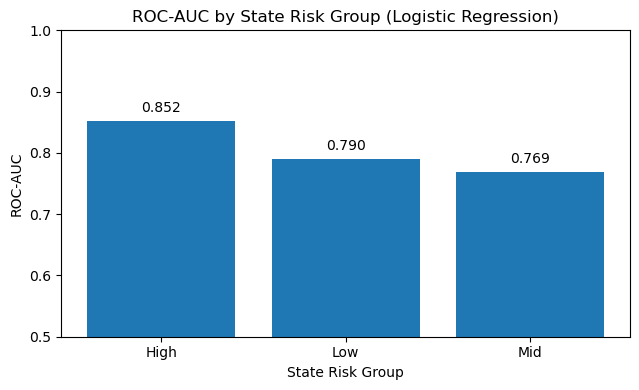

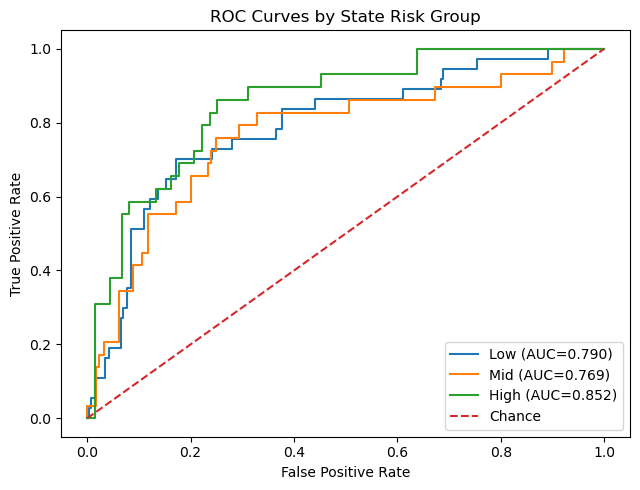

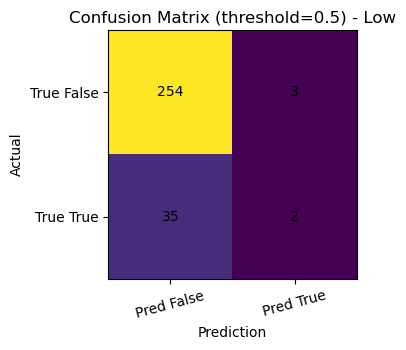

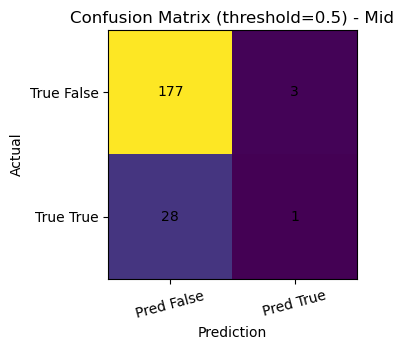

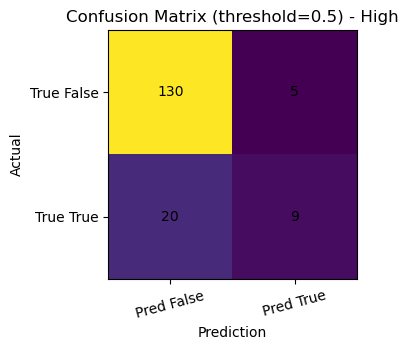

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

# Load data
df = pd.read_csv("churn-bigml-80.csv")
df_test = pd.read_csv("churn-bigml-20.csv")

# --- Build your "State risk group" (Low/Mid/High) based on TRAIN churn rate by State ---
churn_rate_by_state = df.groupby("State")["Churn"].mean()

def risk_map(state):
    rate = churn_rate_by_state.get(state, 0.0)
    if rate > 0.20:
        return "High"
    elif rate > 0.12:
        return "Mid"
    else:
        return "Low"

df["State_risk"] = df["State"].apply(risk_map)
df_test["State_risk"] = df_test["State"].apply(risk_map)

# Features
features = [
    "Total day minutes",
    "Total eve minutes",
    "Total intl minutes",
    "Customer service calls",
    "Number vmail messages"
]

groups = ["Low", "Mid", "High"]
metrics = []
roc_curves = {}
cms = {}

for g in groups:
    train_g = df[df["State_risk"] == g]
    test_g  = df_test[df_test["State_risk"] == g]

    X_train = train_g[features].to_numpy()
    y_train = train_g["Churn"].to_numpy()
    X_test  = test_g[features].to_numpy()
    y_test  = test_g["Churn"].to_numpy()

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_s, y_train)

    y_prob = model.predict_proba(X_test_s)[:, 1]
    y_pred = (y_prob >= 0.5)

    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, thr = roc_curve(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred, labels=[False, True])

    roc_curves[g] = (fpr, tpr, thr)
    cms[g] = cm

    metrics.append({
        "group": g,
        "n_train": len(train_g),
        "n_test": len(test_g),
        "roc_auc": float(auc),
        "tp": int(cm[1,1]),
        "fp": int(cm[0,1]),
        "tn": int(cm[0,0]),
        "fn": int(cm[1,0]),
        "recall_true": float(cm[1,1] / (cm[1,1] + cm[1,0] + 1e-12)),
        "precision_true": float(cm[1,1] / (cm[1,1] + cm[0,1] + 1e-12)),
    })

metrics_df = pd.DataFrame(metrics).sort_values("group")
print(metrics_df)

# --- Visualization 1: ROC-AUC bar chart by group ---
plt.figure(figsize=(6.5, 4.0))
plt.bar(metrics_df["group"], metrics_df["roc_auc"])
plt.ylim(0.5, 1.0)
plt.title("ROC-AUC by State Risk Group (Logistic Regression)")
plt.ylabel("ROC-AUC")
plt.xlabel("State Risk Group")
for i, v in enumerate(metrics_df["roc_auc"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# --- Visualization 2: ROC curves ---
plt.figure(figsize=(6.5, 5.0))
for g in groups:
    fpr, tpr, _ = roc_curves[g]
    auc = metrics_df.loc[metrics_df["group"] == g, "roc_auc"].iloc[0]
    plt.plot(fpr, tpr, label=f"{g} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.title("ROC Curves by State Risk Group")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# --- Visualization 3: Confusion matrices ---
def plot_cm(cm, title):
    plt.figure(figsize=(4.2, 3.6))
    plt.imshow(cm)
    plt.title(title)
    plt.xticks([0, 1], ["Pred False", "Pred True"], rotation=15)
    plt.yticks([0, 1], ["True False", "True True"])
    for (i, j), val in np.ndenumerate(cm):
        plt.text(j, i, str(val), ha="center", va="center")
    plt.xlabel("Prediction")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

for g in groups:
    plot_cm(cms[g], f"Confusion Matrix (threshold=0.5) - {g}")
